# A. Appendix: Exploratory Arms — EXPLORATORY

**What this appendix is.** Three cheap, clearly-labeled, cuttable arms from the PLAN §3
matrix's EXPL rows: **X01** (marginal value of a small cross-encoder reranker over
embedding retrieval), **X02** (entity-ID churn under incremental updates), and **EFF-02**
(a static-distilled encoder ~two orders cheaper at inference). Every section banner, card,
figure caption and verdict below carries the **EXPLORATORY** label, because PLAN §3 defines
these arms as *hypothesis-generating, never headline evidence*: they exist to decide
whether a full pre-registered experiment is worth its compute, and **a negative result is a
welcome finding, stated as such** — "this mechanism does not earn a follow-up at this
scale" is exactly the kind of sentence this appendix is for.

**Discipline unchanged.** Exploratory does not mean sloppy: cards are still registered
before any affected computation, verdicts still score the pre-registered rules, figures
still render only from registered artifacts, splits are still entity-disjoint
(`met07_splits`), and every single-seed reading quotes BOTH MET-04 detectability bars.
Ranking comparisons score **raw scores, rank-natively** (the Wave-4 binding convention:
AUC-style and top-k rankings are invariant only under *strictly* monotone maps, and the
isotonic calibrator is not one); **entity operating points keep calibrated probabilities**.
Each artifact's meta declares the scored representation.

**Scope honesty, up front.** One trained encoder, one seed, one corpus draw, smoke tier:
every verdict says "demonstration". The corpus is `historical_50k`-derived (public
historical records, error-injected); NC data enters only as the aggregate channel rates in
the corpus meta — **no NC person-level value appears anywhere in this notebook, so there is
nothing to mask** (DATA_GOVERNANCE.md).

In [1]:
import time

import faiss
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import sparse
from torch import nn

from er_lab.blocking import ann
from er_lab.cluster.schemes import transitive_closure
from er_lab.config import config_hash, load_config_from_env, set_all_seeds
from er_lab.data.schema import NON_TEXT_ROLES, ROLES
from er_lab.eval.bootstrap import bootstrap_ci, paired_delta
from er_lab.eval.metrics import bcubed
from er_lab.eval.operating_points import find_threshold_for_precision
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.models.encoders import CharByteEncoder, build_encoder
from er_lab.noise.channels import (
    PerRecordChannel,
    field_dropout,
    get_cell,
    hub_value,
    name_order_swap,
    typo,
)
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box
from er_lab.score.calibrate import fit_calibrator
from er_lab.serialize import serialize_frame
from er_lab.train.loop import train_encoder

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()
SECTION_TIMES: list[tuple[str, float]] = []


def tick(label: str, t0: float) -> None:
    """Record and print one section's wall-clock — the smoke budget is measured, not vibes."""
    secs = time.time() - t0
    SECTION_TIMES.append((label, secs))
    print(f"[section timing] {label}: {secs:.0f}s")

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants — three arms, one budget table

The bi-encoder is the **established NB12 recipe** (infonce / in-batch / no augmentation on
the scratch char encoder, the same tier shape-and-steps table as notebooks 09/12/13, same
seed and train slice — so it is bit-for-bit the NB12/NB13 encoder, re-derived). This
appendix's DAG contract requires only `calibrated_corpus`, so the recipe is **stated**
here rather than read from a Wave-4 artifact; the statement is the same table those
notebooks asserted against. The cross-encoder (X01) is the **same budget class**: identical
trunk shape and the identical 250-step x batch-64 optimizer budget, with one stated shape
deviation — a 192-byte window, because its input is a concatenated *pair*. Protocol
constants (precision target, candidate budgets) are PLAN §5/§3; analysis budgets scale with
tier. Smoke budget for the whole notebook: **<= ~30 min uncontended on the 4-CPU
container** (two sibling notebook builds contend for these CPUs; wall-clock can inflate
2-4x — per-section timings print at the end).

In [3]:
TIER = str(cfg.run.tier)
SIZES = {"smoke": 3_000, "mid": None, "target": None, "analytical": 3_000}  # train records
STEPS_BY_TIER = {"smoke": 250, "mid": 2000, "target": 4000, "analytical": 250}
MODEL_SHAPE = {
    "smoke": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
    "mid": {"dim": 256, "layers": 4, "heads": 4, "max_len": 192},
    "target": {"dim": 384, "layers": 6, "heads": 6, "max_len": 192},
    "analytical": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
}[TIER]
STEPS = STEPS_BY_TIER[TIER]
ENC_BATCH = 256  # inference encode batch
N_BOOT = {"smoke": 400, "mid": 1000, "target": 2000, "analytical": 400}[TIER]
PRIMARY_SEED = int(cfg.run.seed)

# X01 — reranker arm
X01_N = {"smoke": 4_000, "mid": None, "target": None, "analytical": 4_000}[TIER]  # arena recs
K_RETR = 25  # retrieval pool per record (the budget being squeezed)
K_KEEP = 10  # kept budget per record after rerank (the k=10-equivalent)
X_MAXLEN = 192  # pair window: two bare-serialized records + ' [SEP] ' (deviation, stated)
X_BATCH = 64  # training batch (32 pos + 32 neg per step — balanced, stated)
X_SCORE_BATCH = 256

# X02 — ID churn arm
GROWTH = 0.10  # +10% corpus growth per increment
NEW_SHARE_TARGET = 0.40  # target share of batch records that are brand-new entities
K_CAND = 10  # candidate budget for clustering graphs (bas02/clu01's noise-slice k)
PREC_TARGET = 0.99  # B-cubed entity-precision operating point (PLAN §5 primary)
GRID = {"smoke": 60, "mid": 120, "target": 200, "analytical": 60}[TIER]

# EFF-02 — static distillation arm
NGRAM_NS = (3, 4)  # char n-gram orders hashed into one table
D_HASH = 4096  # hashed feature dimension
RIDGE_LAMBDA = 1.0  # closed-form ridge regularizer (fixed, untuned — stated)
PC_KS = (5, 10, 25)

cfg.model.kind = "scratch_char"
cfg.model.dim = MODEL_SHAPE["dim"]
cfg.model.layers = MODEL_SHAPE["layers"]
cfg.model.heads = MODEL_SHAPE["heads"]
cfg.model.max_len = MODEL_SHAPE["max_len"]
cfg.train.steps = STEPS
BATCH = int(cfg.train.batch_size)
print(f"tier={TIER}: bi-encoder {MODEL_SHAPE}, steps={STEPS}, batch={BATCH}, train-slice "
      f"budget {SIZES[TIER]}; X01 arena {X01_N}, pool k={K_RETR} -> keep {K_KEEP}, "
      f"cross-encoder window {X_MAXLEN}; X02 growth +{GROWTH:.0%} (target {NEW_SHARE_TARGET:.0%} "
      f"new-entity records), k={K_CAND}, precision@{PREC_TARGET}, grid={GRID}; "
      f"EFF-02 ngrams {NGRAM_NS} -> {D_HASH}-d hash, ridge lambda={RIDGE_LAMBDA}, "
      f"PC at k in {PC_KS}; n_boot={N_BOOT}")

tier=smoke: bi-encoder {'dim': 128, 'layers': 2, 'heads': 4, 'max_len': 128}, steps=250, batch=64, train-slice budget 3000; X01 arena 4000, pool k=25 -> keep 10, cross-encoder window 192; X02 growth +10% (target 40% new-entity records), k=10, precision@0.99, grid=60; EFF-02 ngrams (3, 4) -> 4096-d hash, ridge lambda=1.0, PC at k in (5, 10, 25); n_boot=400


## 1. The arena — corpus, split, bars

`calibrated_corpus` is the declared DAG requirement. `met07_splits` is produced by notebook
05 alongside it (guaranteed present whenever the requirement is, loaded with the same
hard-fail placard semantics), and `met04_power_table` is loaded because the MET-04 bars are
the series-binding caution for every single-seed reading — **both** registered bars are
quoted below and in every verdict.

`TEXT_ROLES` inherits notebook 08's **measured decision**: `full_name` is EXCLUDED — it is
a verbatim join of the name parts that doubles serialized length (forcing truncation at the
smoke byte window) and notebook 05 leaves it stale under nickname/typo edits, so keeping it
would leak the clean name past the injected noise.

In [4]:
t_sec = time.time()
corpus, corpus_meta = registry.load("calibrated_corpus", tier=cfg.run.tier)
splits, _splits_meta = registry.load("met07_splits", tier=cfg.run.tier)
met04, met04_meta = registry.load("met04_power_table", tier=cfg.run.tier)
CORPUS_PROVENANCE = (
    f"calibrated_corpus run {corpus_meta['created_at']} (cfg {corpus_meta['config_hash']}, "
    f"tier {corpus_meta['tier']}, seed {corpus_meta['extra']['seed']})"
)
print(f"corpus: {CORPUS_PROVENANCE}")
print(f"  {len(corpus):,} records / {corpus['entity_id'].nunique():,} entities; "
      f"source={corpus['source'].unique().tolist()} (public historical records; NC enters "
      "only as aggregate channel rates in the corpus meta — nothing to mask)")

# NB08's measured field-set decision, inherited (see the section note above).
TEXT_ROLES = ["given_name", "family_name", "dob", "city", "zip", "sex"]
KEEP_COLS = ["record_id", "entity_id"] + TEXT_ROLES
assert all(r in corpus.columns for r in TEXT_ROLES), "corpus is missing a declared text role"
_loop_roles = [c for c in KEEP_COLS if c in ROLES and c not in NON_TEXT_ROLES]
assert _loop_roles == TEXT_ROLES, (
    f"training-loop role rule would diverge from TEXT_ROLES on KEEP_COLS: {_loop_roles}"
)
print(f"TEXT_ROLES (full_name excluded, NB08 decision) = {TEXT_ROLES}")

SCHEME = "entity_disjoint"
train_ids = set(splits["schemes"][SCHEME]["train"])
eval_ids = set(splits["schemes"][SCHEME]["eval"])
straddle = splits["metadata"]["checks"][SCHEME]["entities_straddling"]
assert straddle == 0, "entity-disjoint split must have zero straddling entities (PLAN §5)"
arena = corpus.reset_index(drop=True)
N_ARENA = len(arena)
train_full = corpus[corpus["record_id"].isin(train_ids)].reset_index(drop=True)
eval_full = corpus[corpus["record_id"].isin(eval_ids)].reset_index(drop=True)
TRUTH_ALL = arena.set_index(arena["record_id"].astype(str))["entity_id"]
print(f"split {SCHEME}: {len(train_full):,} train / {len(eval_full):,} eval records "
      f"({train_full['entity_id'].nunique():,} / {eval_full['entity_id'].nunique():,} "
      "entities, 0 straddling). All three arms train/fit on the train half only and are "
      "scored on the eval half only.")

SER_SCHEME, SER_MISSING = str(cfg.serialize.scheme), str(cfg.serialize.missing)
ARENA_TEXTS = serialize_frame(
    arena, text_roles=TEXT_ROLES, scheme=SER_SCHEME, missing=SER_MISSING
).tolist()
ARENA_POS = pd.Series(np.arange(N_ARENA), index=arena["record_id"].astype(str))
print(f"serialization: scheme={SER_SCHEME} missing={SER_MISSING} (the NB12 recipe's lock)")

# BOTH MET-04 bars, read from the registered meta (the binding convention for any
# single-seed ranking discussion; units are B3F1 at the precision-0.99 point).
BAR_SINGLE = float(met04_meta["extra"]["detect_bar_single_seed"])
BAR_FULL = float(met04_meta["extra"]["detect_bar_residual_inclusive"])
print(f"MET-04 bars (B3F1 units, registered meta; table scope: {met04['scope'].iloc[0]}): "
      f"detect_bar_single_seed = {BAR_SINGLE:.4f}, detect_bar_residual_inclusive = "
      f"{BAR_FULL:.4f}. Single-seed deltas inside these bars are replicate noise by MET-04's "
      "own measurement — every verdict below reads through them, and PC deltas quote them "
      "as the order-of-magnitude caution (PC is a different metric).")
tick("§1 arena + bars", t_sec)

corpus: calibrated_corpus run 2026-08-26T02:41:13.372218+00:00 (cfg 129c9d9243ca, tier smoke, seed 17)
  32,259 records / 2,507 entities; source=['historical_50k'] (public historical records; NC enters only as aggregate channel rates in the corpus meta — nothing to mask)
TEXT_ROLES (full_name excluded, NB08 decision) = ['given_name', 'family_name', 'dob', 'city', 'zip', 'sex']


split entity_disjoint: 16,164 train / 16,095 eval records (1,252 / 1,255 entities, 0 straddling). All three arms train/fit on the train half only and are scored on the eval half only.


serialization: scheme=colval missing=token (the NB12 recipe's lock)
MET-04 bars (B3F1 units, registered meta; table scope: smoke_pilot): detect_bar_single_seed = 0.0862, detect_bar_residual_inclusive = 0.0865. Single-seed deltas inside these bars are replicate noise by MET-04's own measurement — every verdict below reads through them, and PC deltas quote them as the order-of-magnitude caution (PC is a different metric).
[section timing] §1 arena + bars: 1s


## 2. Three conjectures, registered before anything trains — EXPLORATORY

All three cards are registered now — before the shared encoder trains, before a single
candidate pair or distilled weight exists. Decision rules live inside the predictions; the
verdict boxes at the ends of sections 4/5/6 score exactly them. Each conjecture is
explicitly labeled EXPLORATORY: outcomes feed the "should this graduate?" question in the
closing section, never a headline claim.

In [5]:
t_sec = time.time()
_ = conjecture_card(
    card_id="X01",
    conjecture=(
        "EXPLORATORY (PLAN §3 EXPL arm — hypothesis-generating, never headline evidence): "
        "a small cross-encoder reranker buys back most of what a tighter candidate budget "
        "takes away — reading the full pair (both records in one forward pass) lets it "
        "re-order an ANN top-25 pool so that the kept top-10 recovers a large share of the "
        "pair-completeness gap between k=10 and k=25 retrieval — but a cross-encoder runs a "
        "full transformer forward PER PAIR while the bi-encoder amortizes one forward PER "
        "RECORD, so the value must be priced against measured per-pair cost."
    ),
    pressure=(
        "rerank stage {none (keep top-10 by raw cosine), tiny scratch char cross-encoder "
        "(concatenated-pair input: bare-serialized record A + ' [SEP] ' + bare-serialized "
        "record B, 192-byte window; CharByteEncoder trunk of the NB12 tier shape + scalar "
        "head; trained at the NB12 budget class — 250 optimizer steps x batch 64, "
        "balanced 32 pos + 32 neg per step, BCE loss — on entity-disjoint TRAIN-half ANN "
        "top-25 candidate pairs labeled by truth)} applied to the same per-record ANN "
        "top-25 retrieval pool over trained whole-record embeddings (the NB12-recipe "
        "bi-encoder); a pretrained cross-encoder arm is RUN-IN-TARGET mac (HF weights are "
        "blocked in the smoke container)"
    ),
    property=(
        "candidate-ordering quality: pair-completeness of the kept top-10-per-record set "
        "drawn from the identical top-25 pool, under cosine ordering vs cross-encoder "
        "ordering — plus the truth-oracle keep-10 ceiling on the same pool, which bounds "
        "what ANY reranker could recover"
    ),
    metric=(
        "eval-half pair-completeness with entity-resampled percentile-bootstrap 95% CIs on "
        "shared resamples (paired across arms): PC of kept-10-by-cosine (plain k=10), "
        "kept-10-by-cross-encoder (rerank), and the full top-25 pool (the ceiling); "
        "measured ms/pair for the cross-encoder scoring stage and measured per-candidate "
        "cost of the dense retrieval stage (encode amortized + search); all rankings on "
        "RAW scores, rank-natively (Wave-4 binding convention — no calibrated "
        "probabilities in any ranking)"
    ),
    prediction=(
        "P1: reranking recovers at least HALF the budget gap — recovery = "
        "(PC_rerank@10 − PC_cos@10) / (PC@25 − PC_cos@10) >= 0.50 (point estimate, eval "
        "half). P2: the price is bounded — measured cross-encoder ms/pair <= 10x the dense "
        "retrieval stage's measured ms/candidate at k=25 (encode amortized + search, "
        "divided by realized candidates/record). Decision rule, pre-registered: CONFIRMED "
        "iff P1 and P2 both hold; REFUTED iff the paired entity-bootstrap 95% CI on "
        "(PC_rerank@10 − PC_cos@10) lies entirely at or below zero (reranking does not "
        "beat cosine order), or the measured cost ratio exceeds 100x; UNEXPLAINED "
        "otherwise. One trained bi-encoder and one trained cross-encoder (one seed each, "
        "one corpus draw): whatever the outcome, this is an EXPLORATORY demonstration — "
        "the graduation criteria in the closing section say what a pre-registered X01 "
        "experiment would need."
    ),
    registry=registry,
)

### Conjecture card `X01`

| | |
|---|---|
| **Conjecture** | EXPLORATORY (PLAN §3 EXPL arm — hypothesis-generating, never headline evidence): a small cross-encoder reranker buys back most of what a tighter candidate budget takes away — reading the full pair (both records in one forward pass) lets it re-order an ANN top-25 pool so that the kept top-10 recovers a large share of the pair-completeness gap between k=10 and k=25 retrieval — but a cross-encoder runs a full transformer forward PER PAIR while the bi-encoder amortizes one forward PER RECORD, so the value must be priced against measured per-pair cost. |
| **Pressure (dial)** | rerank stage {none (keep top-10 by raw cosine), tiny scratch char cross-encoder (concatenated-pair input: bare-serialized record A + ' [SEP] ' + bare-serialized record B, 192-byte window; CharByteEncoder trunk of the NB12 tier shape + scalar head; trained at the NB12 budget class — 250 optimizer steps x batch 64, balanced 32 pos + 32 neg per step, BCE loss — on entity-disjoint TRAIN-half ANN top-25 candidate pairs labeled by truth)} applied to the same per-record ANN top-25 retrieval pool over trained whole-record embeddings (the NB12-recipe bi-encoder); a pretrained cross-encoder arm is RUN-IN-TARGET mac (HF weights are blocked in the smoke container) |
| **Embedding property** | candidate-ordering quality: pair-completeness of the kept top-10-per-record set drawn from the identical top-25 pool, under cosine ordering vs cross-encoder ordering — plus the truth-oracle keep-10 ceiling on the same pool, which bounds what ANY reranker could recover |
| **System metric** | eval-half pair-completeness with entity-resampled percentile-bootstrap 95% CIs on shared resamples (paired across arms): PC of kept-10-by-cosine (plain k=10), kept-10-by-cross-encoder (rerank), and the full top-25 pool (the ceiling); measured ms/pair for the cross-encoder scoring stage and measured per-candidate cost of the dense retrieval stage (encode amortized + search); all rankings on RAW scores, rank-natively (Wave-4 binding convention — no calibrated probabilities in any ranking) |
| **Pre-registered prediction** | P1: reranking recovers at least HALF the budget gap — recovery = (PC_rerank@10 − PC_cos@10) / (PC@25 − PC_cos@10) >= 0.50 (point estimate, eval half). P2: the price is bounded — measured cross-encoder ms/pair <= 10x the dense retrieval stage's measured ms/candidate at k=25 (encode amortized + search, divided by realized candidates/record). Decision rule, pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff the paired entity-bootstrap 95% CI on (PC_rerank@10 − PC_cos@10) lies entirely at or below zero (reranking does not beat cosine order), or the measured cost ratio exceeds 100x; UNEXPLAINED otherwise. One trained bi-encoder and one trained cross-encoder (one seed each, one corpus draw): whatever the outcome, this is an EXPLORATORY demonstration — the graduation criteria in the closing section say what a pre-registered X01 experiment would need. |

*Immutable — sha256 `7b337313fa16`; registered before the affected runs, never edited (PLAN §5).*


In [6]:
_ = conjecture_card(
    card_id="X02",
    conjecture=(
        "EXPLORATORY (PLAN §3 EXPL arm — hypothesis-generating, never headline evidence): "
        "entity-ID stability and clustering quality trade off under incremental corpus "
        "growth — a full re-cluster from scratch reshuffles the IDs of records whose "
        "neighborhoods the new arrivals perturb, while an incremental attach policy "
        "(new records join an existing cluster iff their best calibrated match clears the "
        "operating threshold, else seed a new cluster) churns no existing ID by "
        "construction but pays for that stability in entity quality, because it can "
        "neither merge nor split existing clusters as evidence accumulates."
    ),
    pressure=(
        "update policy {full re-cluster (rebuild the ANN top-10 candidate graph over the "
        "grown corpus, calibrated probabilities, transitive closure at the FROZEN T0 "
        "operating threshold — threshold transfer, stated), incremental attach (arrivals "
        "processed in arrival order; each joins the cluster of its best-scoring existing "
        "record iff calibrated prob >= the same threshold, else seeds a new cluster)} "
        "after +10% corpus growth on the entity-disjoint eval slice; the arrival batch "
        "mixes ~60% new duplicates of existing T0 entities (spawned through the calibrated "
        "noise channels at the corpus meta's measured rates) with ~40% records of "
        "brand-new entities (whole held-back eval entities the T0 arena never contained)"
    ),
    property=(
        "partition stability restricted to the T0 records: fraction of T0 clusters whose "
        "T0-record membership changed, split and merge counts, and the ID-remap fraction "
        "under max-overlap ID carryover (each T1 cluster inherits the T0 ID it best "
        "overlaps, each ID used once; unmatched clusters get fresh IDs)"
    ),
    metric=(
        "per policy: the churn ledger above plus entity quality at T1 — B-cubed "
        "precision/recall/F1 against truth over all T1 records with entity-unit BCa 95% "
        "CIs, and the paired full-minus-incremental B3F1 delta on shared entity resamples; "
        "operating points on CALIBRATED probabilities (the convention: entity operating "
        "points keep calibrated probs; no ranking metric is computed on them)"
    ),
    prediction=(
        "P1 (the churn asymmetry): full re-cluster remaps >= 1% of T0 records under "
        "max-overlap carryover, while incremental attach remaps exactly 0 — by "
        "construction, verified not assumed. P2 (the price of stability): the paired "
        "full-minus-incremental B3F1 delta at T1 is >= 0 and smaller than the MET-04 "
        "residual-inclusive single-seed bar read from met04_power_table meta. Decision "
        "rule, pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff full "
        "re-cluster remaps < 0.2% of T0 records (the churn problem this arm exists to "
        "probe is imaginary at this scale), or the full-minus-incremental B3F1 delta "
        "exceeds the bar with its paired 95% CI excluding zero (stability is "
        "quality-expensive — the tradeoff is first-order); UNEXPLAINED otherwise. Single "
        "seed, one corpus draw, one growth step: an EXPLORATORY demonstration either way."
    ),
    registry=registry,
)

### Conjecture card `X02`

| | |
|---|---|
| **Conjecture** | EXPLORATORY (PLAN §3 EXPL arm — hypothesis-generating, never headline evidence): entity-ID stability and clustering quality trade off under incremental corpus growth — a full re-cluster from scratch reshuffles the IDs of records whose neighborhoods the new arrivals perturb, while an incremental attach policy (new records join an existing cluster iff their best calibrated match clears the operating threshold, else seed a new cluster) churns no existing ID by construction but pays for that stability in entity quality, because it can neither merge nor split existing clusters as evidence accumulates. |
| **Pressure (dial)** | update policy {full re-cluster (rebuild the ANN top-10 candidate graph over the grown corpus, calibrated probabilities, transitive closure at the FROZEN T0 operating threshold — threshold transfer, stated), incremental attach (arrivals processed in arrival order; each joins the cluster of its best-scoring existing record iff calibrated prob >= the same threshold, else seeds a new cluster)} after +10% corpus growth on the entity-disjoint eval slice; the arrival batch mixes ~60% new duplicates of existing T0 entities (spawned through the calibrated noise channels at the corpus meta's measured rates) with ~40% records of brand-new entities (whole held-back eval entities the T0 arena never contained) |
| **Embedding property** | partition stability restricted to the T0 records: fraction of T0 clusters whose T0-record membership changed, split and merge counts, and the ID-remap fraction under max-overlap ID carryover (each T1 cluster inherits the T0 ID it best overlaps, each ID used once; unmatched clusters get fresh IDs) |
| **System metric** | per policy: the churn ledger above plus entity quality at T1 — B-cubed precision/recall/F1 against truth over all T1 records with entity-unit BCa 95% CIs, and the paired full-minus-incremental B3F1 delta on shared entity resamples; operating points on CALIBRATED probabilities (the convention: entity operating points keep calibrated probs; no ranking metric is computed on them) |
| **Pre-registered prediction** | P1 (the churn asymmetry): full re-cluster remaps >= 1% of T0 records under max-overlap carryover, while incremental attach remaps exactly 0 — by construction, verified not assumed. P2 (the price of stability): the paired full-minus-incremental B3F1 delta at T1 is >= 0 and smaller than the MET-04 residual-inclusive single-seed bar read from met04_power_table meta. Decision rule, pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff full re-cluster remaps < 0.2% of T0 records (the churn problem this arm exists to probe is imaginary at this scale), or the full-minus-incremental B3F1 delta exceeds the bar with its paired 95% CI excluding zero (stability is quality-expensive — the tradeoff is first-order); UNEXPLAINED otherwise. Single seed, one corpus draw, one growth step: an EXPLORATORY demonstration either way. |

*Immutable — sha256 `1dfce1516ef5`; registered before the affected runs, never edited (PLAN §5).*


In [7]:
_ = conjecture_card(
    card_id="EFF-02",
    conjecture=(
        "EXPLORATORY (PLAN §3 EXPL arm — hypothesis-generating, never headline evidence): "
        "most of what the trained char transformer knows about person-record similarity is "
        "surface n-gram evidence, so a STATIC embedding — hashed character n-gram counts "
        "pushed through one linear map distilled from the teacher by closed-form ridge "
        "regression — retains most of the teacher's blocking quality at a large measured "
        "encode speedup, making ~100x-cheaper inference a plausible blocking tier for "
        "scale designs (the EFF-02 question)."
    ),
    pressure=(
        "encoder regime {teacher: the NB12-recipe scratch char transformer (infonce / "
        "in-batch / no augmentation, tier shape table, 250 steps x batch 64), student: a "
        "static lookup — char {3,4}-gram counts hashed to 4096 dims, L2-normalized, times "
        "a single 4096x128 matrix fitted by closed-form ridge regression (lambda 1.0, "
        "untuned) to regress the teacher's embeddings of the entity-disjoint TRAIN-half "
        "records on the identical serialized texts} — the student sees no labels, only the "
        "teacher's geometry"
    ),
    property=(
        "how much of the teacher's retrieval geometry survives the distillation: mean "
        "teacher-student cosine per record (fit half vs eval half), and the resulting "
        "candidate quality — eval-half pair-completeness of ANN top-k retrieval over "
        "student embeddings vs teacher embeddings at matched k"
    ),
    metric=(
        "measured encode throughput (records/s, both models back-to-back on the identical "
        "serialized corpus, same container); PC at k in {5, 10, 25} with entity-bootstrap "
        "95% CIs on shared resamples (raw-cosine retrieval, rank-native — the binding "
        "convention); and entity-level B-cubed F1 at the precision-0.99 operating point "
        "(each model's calibrated probabilities, transitive closure, PLAN §5 loud-fallback "
        "rail) with the paired teacher-minus-student delta"
    ),
    prediction=(
        "P1 (retention): student PC@10 >= 90% of teacher PC@10 (eval half, point "
        "estimates). P2 (speedup): student encode throughput >= 20x the teacher's, both "
        "measured back-to-back on the identical texts. P3 (subordinate, cannot flip the "
        "outcome): the teacher-minus-student B3F1 delta at the precision-0.99 operating "
        "point is within the MET-04 residual-inclusive single-seed bar. Decision rule, "
        "pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff retention < 75% "
        "OR speedup < 5x (the arm is not worth a follow-up in either failure mode); "
        "UNEXPLAINED otherwise. One teacher (one seed, one corpus draw), one ridge fit: "
        "an EXPLORATORY demonstration; the honest conclusion is reported whichever way it "
        "lands."
    ),
    registry=registry,
)
tick("§2 cards", t_sec)

### Conjecture card `EFF-02`

| | |
|---|---|
| **Conjecture** | EXPLORATORY (PLAN §3 EXPL arm — hypothesis-generating, never headline evidence): most of what the trained char transformer knows about person-record similarity is surface n-gram evidence, so a STATIC embedding — hashed character n-gram counts pushed through one linear map distilled from the teacher by closed-form ridge regression — retains most of the teacher's blocking quality at a large measured encode speedup, making ~100x-cheaper inference a plausible blocking tier for scale designs (the EFF-02 question). |
| **Pressure (dial)** | encoder regime {teacher: the NB12-recipe scratch char transformer (infonce / in-batch / no augmentation, tier shape table, 250 steps x batch 64), student: a static lookup — char {3,4}-gram counts hashed to 4096 dims, L2-normalized, times a single 4096x128 matrix fitted by closed-form ridge regression (lambda 1.0, untuned) to regress the teacher's embeddings of the entity-disjoint TRAIN-half records on the identical serialized texts} — the student sees no labels, only the teacher's geometry |
| **Embedding property** | how much of the teacher's retrieval geometry survives the distillation: mean teacher-student cosine per record (fit half vs eval half), and the resulting candidate quality — eval-half pair-completeness of ANN top-k retrieval over student embeddings vs teacher embeddings at matched k |
| **System metric** | measured encode throughput (records/s, both models back-to-back on the identical serialized corpus, same container); PC at k in {5, 10, 25} with entity-bootstrap 95% CIs on shared resamples (raw-cosine retrieval, rank-native — the binding convention); and entity-level B-cubed F1 at the precision-0.99 operating point (each model's calibrated probabilities, transitive closure, PLAN §5 loud-fallback rail) with the paired teacher-minus-student delta |
| **Pre-registered prediction** | P1 (retention): student PC@10 >= 90% of teacher PC@10 (eval half, point estimates). P2 (speedup): student encode throughput >= 20x the teacher's, both measured back-to-back on the identical texts. P3 (subordinate, cannot flip the outcome): the teacher-minus-student B3F1 delta at the precision-0.99 operating point is within the MET-04 residual-inclusive single-seed bar. Decision rule, pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff retention < 75% OR speedup < 5x (the arm is not worth a follow-up in either failure mode); UNEXPLAINED otherwise. One teacher (one seed, one corpus draw), one ridge fit: an EXPLORATORY demonstration; the honest conclusion is reported whichever way it lands. |

*Immutable — sha256 `309f51a6e7f6`; registered before the affected runs, never edited (PLAN §5).*


[section timing] §2 cards: 0s


## 3. Shared instruments — the NB12-recipe encoder, its calibrator, the PC tools

One bi-encoder serves all three arms: trained on the same entity-complete 3,000-record
train slice with the same construction seed as notebooks 09/12/13, so it is the same
encoder those notebooks measured (deterministic under seed). Its measured encode rate is
the teacher throughput EFF-02 compares against and the amortized cost X01's ledger counts.
The calibrator (global isotonic on TRAIN-half ANN candidates + uniform negatives, labeled
by truth) exists so X02's and EFF-02's *operating points* live on the calibrated
probability scale, per convention. It is deliberately leaner than CAL-01's (no matchkey
source, no strata, no held-out reliability claim — NB13 owns those); rankings never touch
it.

In [8]:
def entity_complete_subsample(
    frame: pd.DataFrame, n_records: int | None, rng: np.random.Generator
) -> pd.DataFrame:
    """Random whole entities until ~n_records — an entity is never split across the cut.

    (Same notebook-local helper as notebooks 05/09/12/13 — a shared home in er_lab.data
    would serve; reported as a package gap.)
    """
    if n_records is None or n_records >= len(frame):
        return frame.reset_index(drop=True)
    ents = frame["entity_id"].unique()
    sizes = frame["entity_id"].value_counts()
    picked: list[str] = []
    total = 0
    for i in rng.permutation(len(ents)):
        picked.append(ents[i])
        total += int(sizes[ents[i]])
        if total >= n_records:
            break
    return frame[frame["entity_id"].isin(set(picked))].reset_index(drop=True)


t_sec = time.time()
train_slice = entity_complete_subsample(
    train_full, SIZES[TIER], np.random.default_rng(PRIMARY_SEED)
)[KEEP_COLS]
print(f"train slice: {len(train_slice):,} records / {train_slice['entity_id'].nunique():,} "
      "entities (entity-complete, same construction+seed as NB09/12/13)")

set_all_seeds(PRIMARY_SEED)
encoder = build_encoder(cfg)
N_PARAMS = int(sum(p.numel() for p in encoder.parameters()))
_t0 = time.time()
encoder, hist = train_encoder(
    encoder, train_slice, cfg, loss_name="infonce", miner_name="inbatch",
    augment_kind="none", steps=STEPS, seed=PRIMARY_SEED,
)
TRAIN_SECS = time.time() - _t0
assert len(hist) == STEPS and int(hist["step"].iloc[-1]) == STEPS, (
    f"budget violation: expected exactly {STEPS} optimizer steps, history shows {len(hist)}"
)
print(f"teacher trained (the stated NB12 recipe): infonce/inbatch/none, {STEPS} steps x "
      f"batch {BATCH} (asserted from history), {N_PARAMS:,} params -> {TRAIN_SECS:.0f}s; "
      f"final train loss {float(hist['loss'].tail(20).mean()):.4f}")
tick("§3a teacher train", t_sec)

train slice: 3,010 records / 222 entities (entity-complete, same construction+seed as NB09/12/13)


teacher trained (the stated NB12 recipe): infonce/inbatch/none, 250 steps x batch 64 (asserted from history), 330,880 params -> 36s; final train loss 1.0417
[section timing] §3a teacher train: 36s


In [9]:
t_sec = time.time()
_t0 = time.time()
EMB = encoder.encode(ARENA_TEXTS, batch_size=ENC_BATCH)
ENCODE_SECS = time.time() - _t0
ENC_RATE = N_ARENA / ENCODE_SECS
print(f"encoded {N_ARENA:,} records -> ({EMB.shape[0]:,}, {EMB.shape[1]}) in {ENCODE_SECS:.0f}s "
      f"= {ENC_RATE:,.0f} rec/s on this container ({ENCODE_SECS / N_ARENA * 1e3:.2f} ms/record "
      "amortized; rows L2-normalized so a pair's dot product IS its cosine)")
tick("§3b teacher encode", t_sec)

encoded 32,259 records -> (32,259, 128) in 20s = 1,647 rec/s on this container (0.61 ms/record amortized; rows L2-normalized so a pair's dot product IS its cosine)
[section timing] §3b teacher encode: 20s


In [10]:
def pair_cosines(emb: np.ndarray, pos: pd.Series, a_ids: pd.Series, b_ids: pd.Series):
    """Cosine per pair from an embedding matrix via a record_id -> row map."""
    ia = pos.loc[a_ids.astype(str)].to_numpy()
    ib = pos.loc[b_ids.astype(str)].to_numpy()
    return np.einsum("ij,ij->i", emb[ia], emb[ib]).astype(float)


def true_pair_table(frame: pd.DataFrame) -> pd.DataFrame:
    """All unordered same-entity pairs of *frame* as DataFrame[a, b, entity, key], a<b."""
    rows: list[tuple[str, str, str]] = []
    for ent, grp in frame.groupby("entity_id", sort=True):
        ids = sorted(grp["record_id"].astype(str))
        for i in range(len(ids) - 1):
            for j in range(i + 1, len(ids)):
                rows.append((ids[i], ids[j], str(ent)))
    out = pd.DataFrame(rows, columns=["a", "b", "entity"])
    out["key"] = out["a"] + "||" + out["b"]
    return out


def make_pc_tools(frame: pd.DataFrame, seed: int) -> dict:
    """Entity-bootstrap PC instruments for one eval arena (NB12's machinery, factored).

    One shared resample matrix per arena makes every PC delta on it paired.
    (er_lab.eval.bootstrap targets clusterings, not candidate sets — package gap, noted.)
    """
    pairs = true_pair_table(frame)
    codes, labels = pd.factorize(pairs["entity"])
    n_ent = len(labels)
    boot = np.random.default_rng(seed).integers(0, n_ent, size=(N_BOOT, n_ent))
    t_e = np.bincount(codes, minlength=n_ent).astype(float)
    t_reps = t_e[boot].sum(axis=1)

    def found_mask(keys: set) -> np.ndarray:
        return pairs["key"].isin(keys).to_numpy()

    def reps_of(found: np.ndarray) -> np.ndarray:
        f_e = np.bincount(codes, weights=found.astype(float), minlength=n_ent)
        return f_e[boot].sum(axis=1) / t_reps

    def pc_ci(found: np.ndarray) -> tuple[float, float, float]:
        reps = reps_of(found)
        return (float(found.mean()), float(np.nanpercentile(reps, 2.5)),
                float(np.nanpercentile(reps, 97.5)))

    def delta_ci(fx: np.ndarray, fy: np.ndarray) -> tuple[float, float, float]:
        reps = reps_of(fx) - reps_of(fy)
        return (float(fx.mean() - fy.mean()), float(np.nanpercentile(reps, 2.5)),
                float(np.nanpercentile(reps, 97.5)))

    return {"pairs": pairs, "n_entities": n_ent, "found_mask": found_mask,
            "reps_of": reps_of, "pc_ci": pc_ci, "delta_ci": delta_ci}

In [11]:
# The operating-point calibrator (global isotonic; train half only; stated economies above).
t_sec = time.time()
tr_pos = ARENA_POS.loc[train_full["record_id"].astype(str)].to_numpy()
cal_cand = ann.candidates(train_full, EMB[tr_pos], k=K_CAND, index="flat")
_rng_neg = np.random.default_rng(PRIMARY_SEED + 7)
_tr_ids = train_full["record_id"].astype(str).to_numpy()
_n_neg = len(cal_cand)
_ia = _rng_neg.integers(0, len(_tr_ids), size=int(1.2 * _n_neg))
_ib = _rng_neg.integers(0, len(_tr_ids), size=int(1.2 * _n_neg))
_keep = _ia != _ib
neg_pairs = pd.DataFrame({
    "a": np.minimum(_tr_ids[_ia[_keep]], _tr_ids[_ib[_keep]]),
    "b": np.maximum(_tr_ids[_ia[_keep]], _tr_ids[_ib[_keep]]),
}).drop_duplicates().head(_n_neg)
calpairs = pd.concat(
    [cal_cand.assign(source=f"ann_flat_k{K_CAND}"), neg_pairs.assign(source="uniform_random")],
    ignore_index=True,
)
calpairs["a"], calpairs["b"] = calpairs["a"].astype(str), calpairs["b"].astype(str)
calpairs = calpairs.drop_duplicates(subset=["a", "b"], keep="first").reset_index(drop=True)
calpairs["label"] = (
    TRUTH_ALL.loc[calpairs["a"]].to_numpy() == TRUTH_ALL.loc[calpairs["b"]].to_numpy()
).astype(float)
calpairs["cos"] = pair_cosines(EMB, ARENA_POS, calpairs["a"], calpairs["b"])
iso_teacher = fit_calibrator(calpairs["cos"].to_numpy(), calpairs["label"].to_numpy(),
                             method="isotonic")
print(f"operating-point calibrator: global isotonic on {len(calpairs):,} TRAIN-half pairs "
      f"({dict(calpairs['source'].value_counts())}; positive rate "
      f"{calpairs['label'].mean():.3f}). Used ONLY at entity operating points (X02, EFF-02); "
      "every ranking below scores raw scores rank-natively (binding convention).")
tick("§3c calibrator", t_sec)

operating-point calibrator: global isotonic on 224,946 TRAIN-half pairs ({'ann_flat_k10': 112524, 'uniform_random': 112422}; positive rate 0.325). Used ONLY at entity operating points (X02, EFF-02); every ranking below scores raw scores rank-natively (binding convention).
[section timing] §3c calibrator: 4s


## 4. X01 — the reranker's marginal value, priced — EXPLORATORY

The experiment isolates one variable: **the ordering criterion over an identical top-25
pool**. Per-record directed top-25 neighbor lists come from the same exact flat index the
`blocking.ann` module builds (rebuilt here because the module returns undirected deduped
pairs — a package gap, noted; the union-pair sets are asserted to match the module's).
Plain arm: keep each record's top-10 by raw cosine. Rerank arm: keep its top-10 by raw
cross-encoder logit. Oracle arm: keep true pairs first — the ceiling ANY reranker could
reach on this pool. A pair survives if EITHER endpoint keeps it (the same union semantics
as the module's top-k proposals). PC@25 (the whole pool) bounds the rerank arm by
construction.

In [12]:
t_sec = time.time()
x01_frame = entity_complete_subsample(
    eval_full, X01_N, np.random.default_rng(PRIMARY_SEED + 3)
).reset_index(drop=True)
X01_IDS = x01_frame["record_id"].astype(str).to_numpy()
N_X01 = len(x01_frame)
x01_emb = np.ascontiguousarray(EMB[ARENA_POS.loc[X01_IDS].to_numpy()])
x01_tools = make_pc_tools(x01_frame, PRIMARY_SEED + 41)
BARE_X01 = serialize_frame(
    x01_frame, text_roles=TEXT_ROLES, scheme="bare", missing=SER_MISSING
).tolist()
print(f"X01 arena: {N_X01:,} records / {x01_frame['entity_id'].nunique():,} whole eval "
      f"entities (entity-complete subsample of the eval half; tier budget {X01_N}), "
      f"{len(x01_tools['pairs']):,} true pairs over {x01_tools['n_entities']:,} multi-record "
      f"entities; {N_BOOT} shared entity resamples")

_prev_threads = faiss.omp_get_max_threads()
faiss.omp_set_num_threads(1)  # the ann module's determinism rail, mirrored
try:
    _ix = faiss.IndexFlatIP(x01_emb.shape[1])
    _ix.add(x01_emb)
    _t0 = time.time()
    _, _nbr = _ix.search(x01_emb, min(K_RETR + 1, N_X01))
    SEARCH_SECS = time.time() - _t0
finally:
    faiss.omp_set_num_threads(_prev_threads)
D25 = np.full((N_X01, K_RETR), -1, dtype=np.int64)
for _i in range(N_X01):
    _kept = 0
    for _j in np.asarray(_nbr[_i]).tolist():
        if _j == _i or _j < 0:
            continue
        if _kept >= K_RETR:
            break
        D25[_i, _kept] = _j
        _kept += 1


def pairs_from_kept(kept: np.ndarray) -> set:
    """Union-of-proposals pair keys from per-record kept neighbor columns (-1 = empty)."""
    keys = set()
    for i in range(kept.shape[0]):
        for j in kept[i]:
            if j < 0:
                continue
            a, b = (X01_IDS[i], X01_IDS[j]) if X01_IDS[i] < X01_IDS[j] else (X01_IDS[j],
                                                                             X01_IDS[i])
            keys.add(a + "||" + b)
    return keys


KEYS_25 = pairs_from_kept(D25)
_module_25 = ann.candidates(x01_frame, x01_emb, k=K_RETR, index="flat")
_mkeys = set((_module_25["a"].astype(str) + "||" + _module_25["b"].astype(str)).tolist())
_jac = len(KEYS_25 & _mkeys) / max(len(KEYS_25 | _mkeys), 1)
assert _jac >= 0.999, f"directed lists diverge from blocking.ann candidates (jaccard {_jac})"
print(f"directed top-{K_RETR} lists built (exact flat, 1 faiss thread, {SEARCH_SECS:.1f}s "
      f"search): {len(KEYS_25):,} unique pool pairs; union-pair set matches "
      f"blocking.ann.candidates (jaccard {_jac:.4f})")

F25 = x01_tools["found_mask"](KEYS_25)
F10_COS = x01_tools["found_mask"](pairs_from_kept(D25[:, :K_KEEP]))
PC25, PC25_LO, PC25_HI = x01_tools["pc_ci"](F25)
PC10, PC10_LO, PC10_HI = x01_tools["pc_ci"](F10_COS)
print(f"plain arms (raw-cosine order): PC@{K_KEEP} = {PC10:.4f} [{PC10_LO:.4f},{PC10_HI:.4f}]"
      f", PC@{K_RETR} = {PC25:.4f} [{PC25_LO:.4f},{PC25_HI:.4f}] — the budget gap the "
      f"reranker is asked to close is {PC25 - PC10:+.4f}")
tick("§4a X01 arena + pool", t_sec)

X01 arena: 4,007 records / 314 whole eval entities (entity-complete subsample of the eval half; tier budget 4000), 43,397 true pairs over 252 multi-record entities; 400 shared entity resamples


directed top-25 lists built (exact flat, 1 faiss thread, 0.2s search): 66,126 unique pool pairs; union-pair set matches blocking.ann.candidates (jaccard 1.0000)
plain arms (raw-cosine order): PC@10 = 0.4211 [0.4017,0.4439], PC@25 = 0.6306 [0.5981,0.6634] — the budget gap the reranker is asked to close is +0.2095
[section timing] §4a X01 arena + pool: 1s


### The tiny cross-encoder — NB12 budget class, stated

Trunk: the same `CharByteEncoder` shape as the tier table (dim 128, 2 layers, 4 heads at
smoke) with a 192-byte window — the one stated deviation, because the input is a
concatenated pair (`bare` serialization keeps both records inside the window; the byte
budget is measured below). Head: one linear scalar. Budget: exactly 250 optimizer steps x
batch 64 — the NB12 budget class — as balanced 32 pos + 32 neg draws from TRAIN-half ANN
top-25 candidates labeled by truth (the deployed rerank distribution). Scoring is
symmetric by construction: one canonical a<b pair text, one logit per unordered pair.

In [13]:
class TinyCrossEncoder(nn.Module):
    """Concatenated-pair scratch char cross-encoder: CharByteEncoder trunk + scalar head."""

    def __init__(self, *, dim: int, layers: int, heads: int, max_len: int) -> None:
        super().__init__()
        self.trunk = CharByteEncoder(dim=dim, layers=layers, heads=heads, max_len=max_len)
        self.head = nn.Linear(dim, 1)

    def forward(self, ids: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        return self.head(self.trunk(ids, mask)).squeeze(-1)

    @torch.no_grad()
    def score(self, texts: list[str], *, batch_size: int = 256) -> np.ndarray:
        """Raw logits, one per text; batches sorted by length to cut padding waste."""
        was_training = self.training
        self.eval()
        out = np.empty(len(texts), dtype=np.float32)
        order = np.argsort([len(t) for t in texts], kind="stable")
        for s in range(0, len(order), batch_size):
            idx = order[s: s + batch_size]
            ids, mask = self.trunk.tokenize([texts[i] for i in idx])
            out[idx] = self(ids, mask).float().cpu().numpy()
        if was_training:
            self.train()
        return out


t_sec = time.time()
BARE_TR = serialize_frame(
    train_full, text_roles=TEXT_ROLES, scheme="bare", missing=SER_MISSING
).tolist()
_tr_bare_pos = pd.Series(np.arange(len(train_full)),
                         index=train_full["record_id"].astype(str))
xtr = ann.candidates(train_full, EMB[tr_pos], k=K_RETR, index="flat")
xtr_a = _tr_bare_pos.loc[xtr["a"].astype(str)].to_numpy()
xtr_b = _tr_bare_pos.loc[xtr["b"].astype(str)].to_numpy()
xtr_y = (TRUTH_ALL.loc[xtr["a"].astype(str)].to_numpy()
         == TRUTH_ALL.loc[xtr["b"].astype(str)].to_numpy())
POS_IDX = np.flatnonzero(xtr_y)
NEG_IDX = np.flatnonzero(~xtr_y)
print(f"cross-encoder train pairs: {len(xtr):,} TRAIN-half ann_flat k={K_RETR} candidates "
      f"({len(POS_IDX):,} pos / {len(NEG_IDX):,} neg; positive rate {xtr_y.mean():.3f}) — "
      "balanced 32+32 sampling per step, stated")


def pair_text(texts: list[str], i: int, j: int) -> str:
    return texts[i] + " [SEP] " + texts[j]


set_all_seeds(PRIMARY_SEED + 5)
xenc = TinyCrossEncoder(dim=MODEL_SHAPE["dim"], layers=MODEL_SHAPE["layers"],
                        heads=MODEL_SHAPE["heads"], max_len=X_MAXLEN)
X_PARAMS = int(sum(p.numel() for p in xenc.parameters()))
opt = torch.optim.AdamW(xenc.parameters(), lr=float(cfg.train.lr))
bce = nn.BCEWithLogitsLoss()
rng_x = np.random.default_rng(PRIMARY_SEED + 5)
xenc.train()
_t0 = time.time()
x_losses: list[float] = []
_half = X_BATCH // 2
for _step in range(STEPS):
    pi = POS_IDX[rng_x.integers(0, len(POS_IDX), size=_half)]
    ni = NEG_IDX[rng_x.integers(0, len(NEG_IDX), size=_half)]
    texts = ([pair_text(BARE_TR, xtr_a[i], xtr_b[i]) for i in pi]
             + [pair_text(BARE_TR, xtr_a[i], xtr_b[i]) for i in ni])
    y = torch.tensor([1.0] * _half + [0.0] * _half)
    ids, mask = xenc.trunk.tokenize(texts)
    loss = bce(xenc(ids, mask), y)
    opt.zero_grad()
    loss.backward()
    opt.step()
    x_losses.append(float(loss.detach()))
XTRAIN_SECS = time.time() - _t0
assert len(x_losses) == STEPS, "cross-encoder budget violation"
print(f"cross-encoder trained: {STEPS} steps x batch {X_BATCH} (asserted; the NB12 budget "
      f"class), {X_PARAMS:,} params (window {X_MAXLEN}), lr={float(cfg.train.lr)} -> "
      f"{XTRAIN_SECS:.0f}s; final train BCE {float(np.mean(x_losses[-20:])):.4f}")
tick("§4b cross-encoder train", t_sec)

cross-encoder train pairs: 271,562 TRAIN-half ann_flat k=25 candidates (112,737 pos / 158,825 neg; positive rate 0.415) — balanced 32+32 sampling per step, stated


cross-encoder trained: 250 steps x batch 64 (asserted; the NB12 budget class), 339,201 params (window 192), lr=0.0003 -> 19s; final train BCE 0.6600
[section timing] §4b cross-encoder train: 22s


In [14]:
# Score every unique pool pair once (raw logits, rank-native), then rerank per record.
t_sec = time.time()
PAIR_KEYS = sorted(KEYS_25)
_key_idx = {k: i for i, k in enumerate(PAIR_KEYS)}
_x01_pos = {r: i for i, r in enumerate(X01_IDS)}
PAIR_TEXTS = []
for _k in PAIR_KEYS:
    _a, _b = _k.split("||")
    PAIR_TEXTS.append(pair_text(BARE_X01, _x01_pos[_a], _x01_pos[_b]))
_blens = np.array([len(t.encode("utf-8")) for t in PAIR_TEXTS])
print(f"{len(PAIR_TEXTS):,} unique pool pairs to score; pair text median "
      f"{int(np.median(_blens))} bytes, {(_blens > X_MAXLEN - 1).mean():.1%} exceed the "
      f"{X_MAXLEN}-byte window (truncated — the window honesty check)")
_t0 = time.time()
XLOGITS = xenc.score(PAIR_TEXTS, batch_size=X_SCORE_BATCH)
XSCORE_SECS = time.time() - _t0
X_MS_PER_PAIR = XSCORE_SECS / len(PAIR_TEXTS) * 1e3
print(f"scored in {XSCORE_SECS:.0f}s = {X_MS_PER_PAIR:.2f} ms/pair "
      f"({len(PAIR_TEXTS) / XSCORE_SECS:,.0f} pairs/s on this container)")


def rerank_kept(order_scores: np.ndarray) -> np.ndarray:
    """Per record: keep top-K_KEEP of its directed pool by score desc (stable ->
    cosine-rank tiebreak, since D25 columns are already cosine-descending)."""
    kept = np.full((N_X01, K_KEEP), -1, dtype=np.int64)
    for i in range(N_X01):
        js = D25[i][D25[i] >= 0]
        if len(js) == 0:
            continue
        sc = order_scores[[_key_idx[
            (X01_IDS[i] + "||" + X01_IDS[j]) if X01_IDS[i] < X01_IDS[j]
            else (X01_IDS[j] + "||" + X01_IDS[i])] for j in js]]
        top = np.argsort(-sc, kind="stable")[:K_KEEP]
        kept[i, : len(top)] = js[top]
    return kept


F10_X = x01_tools["found_mask"](pairs_from_kept(rerank_kept(XLOGITS)))
PC10X, PC10X_LO, PC10X_HI = x01_tools["pc_ci"](F10_X)

# the oracle ceiling: keep true pairs first — what ANY reranker could recover on this pool
_truth_x01 = x01_frame.set_index(x01_frame["record_id"].astype(str))["entity_id"]
_pair_true = np.array([
    _truth_x01.loc[k.split("||")[0]] == _truth_x01.loc[k.split("||")[1]] for k in PAIR_KEYS
], dtype=float)
F10_ORACLE = x01_tools["found_mask"](pairs_from_kept(rerank_kept(_pair_true)))
PC10O, PC10O_LO, PC10O_HI = x01_tools["pc_ci"](F10_ORACLE)

D_RERANK, D_LO, D_HI = x01_tools["delta_ci"](F10_X, F10_COS)
with np.errstate(divide="ignore", invalid="ignore"):
    _rr = ((x01_tools["reps_of"](F10_X) - x01_tools["reps_of"](F10_COS))
           / (x01_tools["reps_of"](F25) - x01_tools["reps_of"](F10_COS)))
_rr = _rr[np.isfinite(_rr)]
RECOVERY = float((PC10X - PC10) / (PC25 - PC10)) if PC25 > PC10 else float("nan")
REC_LO, REC_HI = float(np.percentile(_rr, 2.5)), float(np.percentile(_rr, 97.5))
ORACLE_REC = float((PC10O - PC10) / (PC25 - PC10)) if PC25 > PC10 else float("nan")
print(f"\nrerank PC@{K_KEEP} = {PC10X:.4f} [{PC10X_LO:.4f},{PC10X_HI:.4f}] vs cosine "
      f"PC@{K_KEEP} = {PC10:.4f}: paired delta {D_RERANK:+.4f} [{D_LO:+.4f},{D_HI:+.4f}]")
print(f"recovery of the k={K_KEEP}->k={K_RETR} gap: {RECOVERY:.3f} "
      f"[{REC_LO:.3f},{REC_HI:.3f}] ({len(_rr)}/{N_BOOT} finite resamples); the truth-oracle "
      f"ceiling on this pool recovers {ORACLE_REC:.3f} (PC {PC10O:.4f} "
      f"[{PC10O_LO:.4f},{PC10O_HI:.4f}]) — no keep-{K_KEEP} reranker can beat that")

# the cost ledger, measured
DENSE_MS_PER_REC = ENCODE_SECS / N_ARENA * 1e3 + SEARCH_SECS / N_X01 * 1e3
CAND_PER_REC = 2.0 * len(KEYS_25) / N_X01
DENSE_MS_PER_CAND = DENSE_MS_PER_REC / CAND_PER_REC
COST_RATIO = X_MS_PER_PAIR / DENSE_MS_PER_CAND
print(f"\ncost ledger (measured, this container): dense retrieval "
      f"{ENCODE_SECS / N_ARENA * 1e3:.2f} encode + {SEARCH_SECS / N_X01 * 1e3:.2f} search "
      f"= {DENSE_MS_PER_REC:.2f} ms/record at k={K_RETR} ({CAND_PER_REC:.1f} realized "
      f"cand/rec) -> {DENSE_MS_PER_CAND:.4f} ms/candidate; cross-encoder "
      f"{X_MS_PER_PAIR:.2f} ms/pair -> cost ratio {COST_RATIO:.0f}x (P2 bar: <= 10x; "
      "cross-encoder training amortization excluded from the ratio, stated)")
tick("§4c score + rerank + ledger", t_sec)

66,126 unique pool pairs to score; pair text median 106 bytes, 0.0% exceed the 192-byte window (truncated — the window honesty check)


scored in 38s = 0.58 ms/pair (1,733 pairs/s on this container)



rerank PC@10 = 0.3808 [0.3579,0.4056] vs cosine PC@10 = 0.4211: paired delta -0.0403 [-0.0580,-0.0244]
recovery of the k=10->k=25 gap: -0.192 [-0.302,-0.108] (400/400 finite resamples); the truth-oracle ceiling on this pool recovers 0.138 (PC 0.4500 [0.4296,0.4746]) — no keep-10 reranker can beat that

cost ledger (measured, this container): dense retrieval 0.61 encode + 0.05 search = 0.65 ms/record at k=25 (33.0 realized cand/rec) -> 0.0198 ms/candidate; cross-encoder 0.58 ms/pair -> cost ratio 29x (P2 bar: <= 10x; cross-encoder training amortization excluded from the ratio, stated)
[section timing] §4c score + rerank + ledger: 39s


In [15]:
# [RUN-IN-TARGET mac] the pretrained cross-encoder arm: HF weights are blocked in this
# container (notes/COMPAT.md go/no-go tree), so the pretrained rerank runs where internet
# is normal — same cells, tier=mid on the mac. The gated branch below is the real code path.
PRETRAINED_XENC_READY = cfg.paths.hf_local is not None or TIER in ("mid", "target")
if PRETRAINED_XENC_READY:
    from sentence_transformers import CrossEncoder

    _ce = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    _t0 = time.time()
    _plog = np.asarray(_ce.predict(
        [tuple(BARE_X01[_x01_pos[p]] for p in k.split("||")) for k in PAIR_KEYS],
        batch_size=X_SCORE_BATCH, show_progress_bar=False), dtype=np.float32)
    _p_secs = time.time() - _t0
    _fp = x01_tools["found_mask"](pairs_from_kept(rerank_kept(_plog)))
    _pc, _lo, _hi = x01_tools["pc_ci"](_fp)
    PRETRAINED_ROW = {"row_type": "arm", "arm": "rerank_pretrained_k10", "pc": _pc,
                      "pc_lo": _lo, "pc_hi": _hi, "kept_pairs": float(_fp.sum()),
                      "score_ms_per_pair": _p_secs / len(PAIR_KEYS) * 1e3,
                      "basis": "MEASURED"}
    print(f"[pretrained arm] ms-marco-MiniLM-L-6-v2 rerank PC@{K_KEEP} = {_pc:.4f} "
          f"[{_lo:.4f},{_hi:.4f}] at {_p_secs / len(PAIR_KEYS) * 1e3:.2f} ms/pair")
else:
    PRETRAINED_ROW = None
    print(f"[RUN-IN-TARGET mac] pretrained cross-encoder arm — not runnable here "
          f"(hf_local={cfg.paths.hf_local!r}, tier={TIER}). Priced from THIS run's "
          "measured coefficients:")
    print(f"  {len(PAIR_TEXTS):,} pool pairs to score; the tiny scratch cross-encoder "
          f"measured {X_MS_PER_PAIR:.2f} ms/pair on 4 CPUs. A MiniLM-class pretrained "
          "cross-encoder is ~20x the parameters; on the mac's MPS, PLAN §8's planning "
          "anchors put it at ~1-3k pairs/s (±2x) -> "
          f"~{len(PAIR_TEXTS) / 2000 / 60:.0f} min for this pool, minutes not hours.")
    print("  What it settles: whether pretrained pair-reading closes more of the gap than "
          "the scratch reranker at the same kept budget — the scratch arm above is the "
          "smoke-tier stand-in, per the §3 encoder gate.")

[RUN-IN-TARGET mac] pretrained cross-encoder arm — not runnable here (hf_local=None, tier=smoke). Priced from THIS run's measured coefficients:
  66,126 pool pairs to score; the tiny scratch cross-encoder measured 0.58 ms/pair on 4 CPUs. A MiniLM-class pretrained cross-encoder is ~20x the parameters; on the mac's MPS, PLAN §8's planning anchors put it at ~1-3k pairs/s (±2x) -> ~1 min for this pool, minutes not hours.
  What it settles: whether pretrained pair-reading closes more of the gap than the scratch reranker at the same kept budget — the scratch arm above is the smoke-tier stand-in, per the §3 encoder gate.


In [16]:
t_sec = time.time()
x01_rows = [
    {"row_type": "arm", "arm": "plain_cos_k10", "pc": PC10, "pc_lo": PC10_LO,
     "pc_hi": PC10_HI, "kept_pairs": float(F10_COS.sum()),
     "retrieval_ms_per_rec": DENSE_MS_PER_REC, "basis": "MEASURED"},
    {"row_type": "arm", "arm": "rerank_cross_k10", "pc": PC10X, "pc_lo": PC10X_LO,
     "pc_hi": PC10X_HI, "kept_pairs": float(F10_X.sum()),
     "retrieval_ms_per_rec": DENSE_MS_PER_REC, "score_ms_per_pair": X_MS_PER_PAIR,
     "basis": "MEASURED"},
    {"row_type": "arm", "arm": "oracle_k10", "pc": PC10O, "pc_lo": PC10O_LO,
     "pc_hi": PC10O_HI, "kept_pairs": float(F10_ORACLE.sum()), "basis": "MEASURED"},
    {"row_type": "arm", "arm": "pool_k25_ceiling", "pc": PC25, "pc_lo": PC25_LO,
     "pc_hi": PC25_HI, "kept_pairs": float(F25.sum()),
     "retrieval_ms_per_rec": DENSE_MS_PER_REC, "basis": "MEASURED"},
    {"row_type": "delta", "arm": "rerank_minus_cos", "delta": D_RERANK, "delta_lo": D_LO,
     "delta_hi": D_HI, "recovery": RECOVERY, "recovery_lo": REC_LO, "recovery_hi": REC_HI,
     "oracle_recovery": ORACLE_REC, "basis": "MEASURED"},
    {"row_type": "cost", "arm": "ledger", "encode_ms_per_rec": ENCODE_SECS / N_ARENA * 1e3,
     "search_ms_per_rec": SEARCH_SECS / N_X01 * 1e3,
     "dense_ms_per_candidate": DENSE_MS_PER_CAND, "score_ms_per_pair": X_MS_PER_PAIR,
     "cost_ratio": COST_RATIO, "basis": "MEASURED"},
]
if PRETRAINED_ROW is not None:
    x01_rows.insert(2, PRETRAINED_ROW)
x01_df = pd.DataFrame(x01_rows)
registry.register(
    "x01_reranker_value", x01_df, cfg=cfg, tier=cfg.run.tier,
    meta={
        "card": "X01",
        "status": "EXPLORATORY (PLAN §3 EXPL arm) — hypothesis-generating, never headline "
                  "evidence",
        "design": f"identical ANN top-{K_RETR} pool per record over the {N_X01}-record "
                  f"entity-complete eval subarena; arms differ ONLY in the keep-{K_KEEP} "
                  "ordering criterion (raw cosine vs raw cross-encoder logit vs truth "
                  "oracle); pair survives if either endpoint keeps it (union semantics)",
        "scored_representation": "RAW scores, rank-native (Wave-4 binding convention): "
                                 "raw cosine for retrieval/plain arms, raw cross-encoder "
                                 "logit for the rerank arm; no calibrated probabilities "
                                 "touch any ranking in this artifact",
        "cross_encoder": {"trunk": {"dim": MODEL_SHAPE["dim"],
                                    "layers": MODEL_SHAPE["layers"],
                                    "heads": MODEL_SHAPE["heads"], "max_len": X_MAXLEN},
                          "n_params": X_PARAMS,
                          "budget": f"{STEPS} steps x batch {X_BATCH} (the NB12 budget "
                                    "class; balanced 32 pos + 32 neg per step, BCE)",
                          "train_pairs": f"TRAIN-half ann_flat k={K_RETR} candidates "
                                         "labeled by truth",
                          "pair_input": "bare-serialized A + ' [SEP] ' + bare-serialized "
                                        "B, canonical a<b; symmetric one-logit-per-pair",
                          "train_secs": XTRAIN_SECS},
        "encoder_recipe": {"statement": "NB12 recipe stated, not read (this appendix's "
                                        "DAG requires only calibrated_corpus): "
                                        "infonce/inbatch/none, scratch_char",
                           "model": dict(MODEL_SHAPE), "steps": STEPS, "batch": BATCH,
                           "n_params": N_PARAMS, "text_roles": TEXT_ROLES,
                           "field_set_note": "full_name excluded per NB08's measured "
                                             "decision (truncation + stale-sync leak)"},
        "ci": {"unit": "entity", "method": "percentile bootstrap", "n_boot": N_BOOT,
               "paired": "shared resample matrix across arms"},
        "cost_note": "cost_ratio = cross-encoder ms/pair over dense retrieval ms/candidate "
                     "(encode amortized over the full corpus + measured 1-thread flat "
                     "search, / realized candidates per record); cross-encoder TRAINING "
                     "cost excluded from the ratio, reported separately",
        "pretrained_arm": ("measured (see rerank_pretrained_k10 row)" if PRETRAINED_ROW
                           else "RUN-IN-TARGET mac (HF blocked here; placard printed with "
                                "measured-coefficient estimates)"),
        "met04": {"detect_bar_single_seed": BAR_SINGLE,
                  "detect_bar_residual_inclusive": BAR_FULL,
                  "units": "B3F1 — quoted as the order-of-magnitude caution for "
                           "single-encoder PC readings, not a PC bar"},
        "single_seed_caveat": "one bi-encoder + one cross-encoder (one seed each, one "
                              "corpus draw) — an EXPLORATORY demonstration",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"registered x01_reranker_value ({len(x01_df)} rows)")
display(x01_df[x01_df["row_type"] == "arm"][["arm", "pc", "pc_lo", "pc_hi"]].round(4))

registered x01_reranker_value (6 rows)


,arm,pc,pc_lo,pc_hi
0,plain_cos_k10,0.4211,0.4017,0.4439
1,rerank_cross_k10,0.3808,0.3579,0.4056
2,oracle_k10,0.4500,0.4296,0.4746
3,pool_k25_ceiling,0.6306,0.5981,0.6634


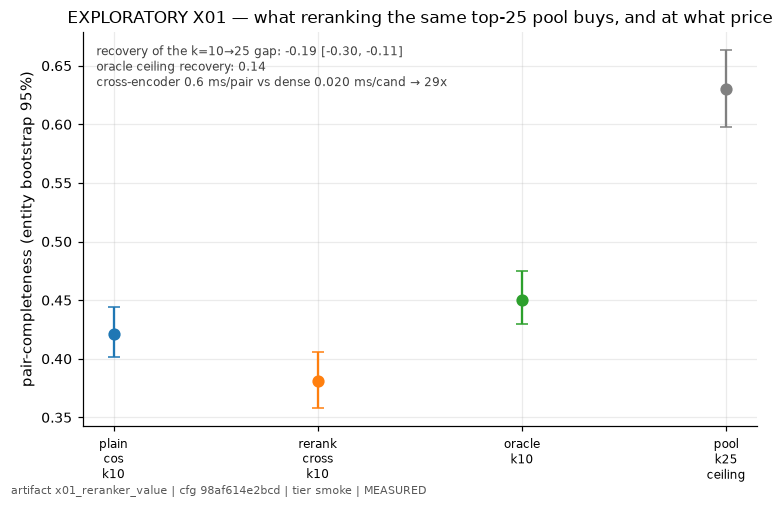

In [17]:
def draw_x01(ax, df, meta):
    arms = df[df["row_type"] == "arm"]
    order = [a for a in ("plain_cos_k10", "rerank_cross_k10", "rerank_pretrained_k10",
                         "oracle_k10", "pool_k25_ceiling") if a in set(arms["arm"])]
    xs = {a: i for i, a in enumerate(order)}
    for _, r in arms.iterrows():
        if r["arm"] not in xs:
            continue
        x = xs[r["arm"]]
        color = {"plain_cos_k10": "C0", "rerank_cross_k10": "C1",
                 "rerank_pretrained_k10": "C4", "oracle_k10": "C2",
                 "pool_k25_ceiling": "0.5"}[r["arm"]]
        ax.errorbar([x], [r["pc"]], yerr=[[r["pc"] - r["pc_lo"]], [r["pc_hi"] - r["pc"]]],
                    fmt="o", capsize=4, markersize=7, color=color)
    d = df[df["row_type"] == "delta"].iloc[0]
    c = df[df["row_type"] == "cost"].iloc[0]
    ax.text(0.02, 0.97,
            f"recovery of the k=10→25 gap: {d['recovery']:.2f} "
            f"[{d['recovery_lo']:.2f}, {d['recovery_hi']:.2f}]\n"
            f"oracle ceiling recovery: {d['oracle_recovery']:.2f}\n"
            f"cross-encoder {c['score_ms_per_pair']:.1f} ms/pair vs dense "
            f"{c['dense_ms_per_candidate']:.3f} ms/cand → {c['cost_ratio']:.0f}x",
            transform=ax.transAxes, va="top", fontsize=8, color="0.25")
    ax.set_xticks(range(len(order)),
                  [a.replace("_", "\n") for a in order], fontsize=8)
    ax.set_ylabel("pair-completeness (entity bootstrap 95%)")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="x01_reranker_value", draw=draw_x01,
    title="EXPLORATORY X01 — what reranking the same top-25 pool buys, and at what price",
    figsize=(7.0, 4.6),
)

### Verdict — X01, scored against the card — EXPLORATORY

In [18]:
p1_x01 = bool(RECOVERY >= 0.50)
p2_x01 = bool(COST_RATIO <= 10.0)
refute_x01 = bool(D_HI <= 0.0 or COST_RATIO > 100.0)
x01_outcome = ("REFUTED" if refute_x01
               else "CONFIRMED" if (p1_x01 and p2_x01) else "UNEXPLAINED")
print(f"P1 (recovery >= 0.50): {RECOVERY:.3f} [{REC_LO:.3f},{REC_HI:.3f}] -> {p1_x01}")
print(f"P2 (cost ratio <= 10x): {COST_RATIO:.0f}x -> {p2_x01}")
print(f"REFUTED clause (rerank delta CI at/below 0: {bool(D_HI <= 0.0)}; ratio > 100x: "
      f"{bool(COST_RATIO > 100.0)}) -> {refute_x01}")
print(f"-> outcome: {x01_outcome}")

_ = verdict_box(
    "X01",
    outcome=x01_outcome,
    evidence=(
        f"EXPLORATORY arm — hypothesis-generating, never headline evidence. "
        f"x01_reranker_value (tier {TIER}; {N_X01:,}-record entity-complete eval "
        f"subarena, {len(x01_tools['pairs']):,} true pairs, {N_BOOT} shared entity "
        f"resamples). P1 {p1_x01}: recovery {RECOVERY:.3f} [{REC_LO:.3f}, {REC_HI:.3f}] "
        f"of the PC@{K_KEEP}={PC10:.4f} -> PC@{K_RETR}={PC25:.4f} gap (rerank "
        f"PC {PC10X:.4f}, paired delta {D_RERANK:+.4f} [{D_LO:+.4f}, {D_HI:+.4f}]; the "
        f"truth-oracle ceiling on the same pool recovers {ORACLE_REC:.3f}). P2 {p2_x01}: "
        f"measured {X_MS_PER_PAIR:.2f} ms/pair cross-encoder vs "
        f"{DENSE_MS_PER_CAND:.4f} ms/candidate dense = {COST_RATIO:.0f}x against the "
        f"pre-registered 10x bar. Mechanism note: the reranker's final train BCE was "
        f"{float(np.mean(x_losses[-20:])):.3f} vs the 0.693 (ln 2) chance level — at this "
        "budget class the scratch cross-encoder barely learns pair-reading, so the "
        "hypothesis a graduated X01 would test is whether budget/pretraining, not "
        "pair-reading itself, is the binding constraint. Single-seed DEMONSTRATION: one "
        "bi-encoder + one "
        f"cross-encoder, one corpus draw — MET-04 bars detect_bar_single_seed "
        f"{BAR_SINGLE:.4f} / detect_bar_residual_inclusive {BAR_FULL:.4f} B3F1 are the "
        "order-of-magnitude caution for margins of this size, and the pretrained "
        "cross-encoder arm is RUN-IN-TARGET mac. Whatever the verdict, the number that "
        "decides adoption is value per cost, and it is printed above, honestly."
    ),
    registry=registry,
)
tick("§4d X01 register + verdict", t_sec)

P1 (recovery >= 0.50): -0.192 [-0.302,-0.108] -> False
P2 (cost ratio <= 10x): 29x -> False
REFUTED clause (rerank delta CI at/below 0: True; ratio > 100x: False) -> True
-> outcome: REFUTED


> ### VERDICT: REFUTED — card `X01`
>
> **Conjecture** EXPLORATORY (PLAN §3 EXPL arm — hypothesis-generating, never headline evidence): a small cross-encoder reranker buys back most of what a tighter candidate budget takes away — reading the full pair (both records in one forward pass) lets it re-order an ANN top-25 pool so that the kept top-10 recovers a large share of the pair-completeness gap between k=10 and k=25 retrieval — but a cross-encoder runs a full transformer forward PER PAIR while the bi-encoder amortizes one forward PER RECORD, so the value must be priced against measured per-pair cost.
>
> **Prediction** P1: reranking recovers at least HALF the budget gap — recovery = (PC_rerank@10 − PC_cos@10) / (PC@25 − PC_cos@10) >= 0.50 (point estimate, eval half). P2: the price is bounded — measured cross-encoder ms/pair <= 10x the dense retrieval stage's measured ms/candidate at k=25 (encode amortized + search, divided by realized candidates/record). Decision rule, pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff the paired entity-bootstrap 95% CI on (PC_rerank@10 − PC_cos@10) lies entirely at or below zero (reranking does not beat cosine order), or the measured cost ratio exceeds 100x; UNEXPLAINED otherwise. One trained bi-encoder and one trained cross-encoder (one seed each, one corpus draw): whatever the outcome, this is an EXPLORATORY demonstration — the graduation criteria in the closing section say what a pre-registered X01 experiment would need.
>
> **Evidence** EXPLORATORY arm — hypothesis-generating, never headline evidence. x01_reranker_value (tier smoke; 4,007-record entity-complete eval subarena, 43,397 true pairs, 400 shared entity resamples). P1 False: recovery -0.192 [-0.302, -0.108] of the PC@10=0.4211 -> PC@25=0.6306 gap (rerank PC 0.3808, paired delta -0.0403 [-0.0580, -0.0244]; the truth-oracle ceiling on the same pool recovers 0.138). P2 False: measured 0.58 ms/pair cross-encoder vs 0.0198 ms/candidate dense = 29x against the pre-registered 10x bar. Mechanism note: the reranker's final train BCE was 0.660 vs the 0.693 (ln 2) chance level — at this budget class the scratch cross-encoder barely learns pair-reading, so the hypothesis a graduated X01 would test is whether budget/pretraining, not pair-reading itself, is the binding constraint. Single-seed DEMONSTRATION: one bi-encoder + one cross-encoder, one corpus draw — MET-04 bars detect_bar_single_seed 0.0862 / detect_bar_residual_inclusive 0.0865 B3F1 are the order-of-magnitude caution for margins of this size, and the pretrained cross-encoder arm is RUN-IN-TARGET mac. Whatever the verdict, the number that decides adoption is value per cost, and it is printed above, honestly.


[section timing] §4d X01 register + verdict: 0s


## 5. X02 — entity-ID churn under incremental updates — EXPLORATORY

Production ER pipelines rarely re-cluster from scratch: records arrive, and every ID remap
breaks a downstream join. This arm simulates one +10% growth step on the eval slice.
**T0**: cluster the arena (calibrated probs, transitive closure at the B-cubed
precision-0.99 threshold — NB13's protocol operating point). **T1**: a documented arrival
mix — new duplicates of existing entities spawned through the calibrated channels at the
corpus meta's measured rates, plus whole held-back eval entities as brand-new people.
Policies: full re-cluster at the frozen T0 threshold (threshold transfer, stated) vs
incremental best-match attach. The finding is the churn-vs-quality tradeoff, whichever way
it lands.

In [19]:
t_sec = time.time()
_rng_hold = np.random.default_rng(PRIMARY_SEED + 23)
_target_new = NEW_SHARE_TARGET * GROWTH / (1.0 + NEW_SHARE_TARGET * GROWTH) * len(eval_full)
heldback = entity_complete_subsample(eval_full, int(_target_new), _rng_hold)
HELD_ENTS = set(heldback["entity_id"])
r0_frame = eval_full[~eval_full["entity_id"].isin(HELD_ENTS)].reset_index(drop=True)
N_R0 = len(r0_frame)
R0_IDS = r0_frame["record_id"].astype(str).to_numpy()
r0_emb = np.ascontiguousarray(EMB[ARENA_POS.loc[R0_IDS].to_numpy()])
truth_r0 = r0_frame.set_index(r0_frame["record_id"].astype(str))["entity_id"]
print(f"T0 arena: {N_R0:,} records / {r0_frame['entity_id'].nunique():,} entities "
      f"(eval half minus {len(HELD_ENTS)} held-back entities = {len(heldback):,} records "
      "reserved as brand-new T1 arrivals)")

cand_r0 = ann.candidates(r0_frame, r0_emb, k=K_CAND, index="flat")
g0 = cand_r0[["a", "b"]].copy()
g0["a"], g0["b"] = g0["a"].astype(str), g0["b"].astype(str)
g0["cos"] = pair_cosines(EMB, ARENA_POS, g0["a"], g0["b"])
g0["prob"] = iso_teacher.transform(g0["cos"].to_numpy())
g0["score"] = g0["prob"]
records_r0 = pd.Index(R0_IDS)
T0_CACHE: dict[float, pd.Series] = {}


def closure_t0(t: float) -> pd.Series:
    t = float(t)
    if t not in T0_CACHE:
        T0_CACHE[t] = transitive_closure(g0, threshold=t, records=records_r0)
    return T0_CACHE[t]


res_t0 = find_threshold_for_precision(
    g0[["a", "b", "score"]], closure_t0, truth_r0, target=PREC_TARGET, grid=GRID)
T_STAR = float(res_t0["threshold"])
if not res_t0["attained"]:
    print(f"  <-- precision {PREC_TARGET} UNATTAINABLE at T0 (fallback="
          f"'{res_t0['fallback']}', best {res_t0['attained_precision']:.4f}) — PLAN §5 "
          "rail: reported loudly, never switched silently")
C0 = closure_t0(T_STAR)
b3_t0 = bcubed(C0, truth_r0)
print(f"T0 operating point (calibrated probs, transitive closure): t*={T_STAR:.6f} "
      f"(attained={res_t0['attained']}), B3 P={b3_t0['precision']:.4f} "
      f"R={b3_t0['recall']:.4f} F={b3_t0['f1']:.4f}; {C0.nunique():,} clusters over "
      f"{N_R0:,} records")

# invert the isotonic map once: attach tests run on cosine >= COS_CUT <=> prob >= t*
_cgrid = np.unique(np.concatenate([calpairs["cos"].to_numpy(), np.linspace(-1, 1, 2001)]))
_pgrid = iso_teacher.transform(_cgrid)
_okc = np.flatnonzero(_pgrid >= T_STAR)
COS_CUT = float(_cgrid[_okc[0]]) if len(_okc) else float("inf")
print(f"prob >= t* corresponds to raw cosine >= {COS_CUT:.4f} (isotonic step inversion; "
      "used only to vectorize the attach test — the operating scale stays calibrated)")
tick("§5a X02 T0 cluster", t_sec)

T0 arena: 15,471 records / 1,218 entities (eval half minus 37 held-back entities = 624 records reserved as brand-new T1 arrivals)


T0 operating point (calibrated probs, transitive closure): t*=0.972096 (attained=True), B3 P=0.9901 R=0.4050 F=0.5748; 4,908 clusters over 15,471 records
prob >= t* corresponds to raw cosine >= 0.9490 (isotonic step inversion; used only to vectorize the attach test — the operating scale stays calibrated)
[section timing] §5a X02 T0 cluster: 9s


### The arrival batch — calibrated dirt, documented mix

Duplicate arrivals pass through the **same channel family at the corpus meta's measured
rates** (NB05's calibrated machine): the package channels directly, plus compact clones of
NB05's custom `move` / `name_change` / `name_format_drift` channels (pool redraw and
skeleton-preserving drift — re-implemented here because NB05 defines them in-notebook;
package gap noted). Two stated deviations: the `nickname` channel is skipped (its
calibrated rate predicts well under one event in a batch this size — the expected count is
printed) and `full_name` is not re-synced (it is excluded from TEXT_ROLES, so nothing
downstream reads it). At calibrated rates most duplicates are exact copies — same as the
corpus itself (NB12 §6 measured this); the churn mechanism under test is index/graph
perturbation, not record noise, and the realized edit counts are printed.

In [20]:
def pool_redraw_channel(name: str, fields: tuple, pool: list) -> PerRecordChannel:
    """Wholesale joint redraw of ``fields`` from a pool of real value tuples (NB05 clone)."""
    def edit(out: pd.DataFrame, pos: int, rng: np.random.Generator) -> list:
        cur = tuple(get_cell(out, pos, f) for f in fields)
        if all(v is None for v in cur) or not pool:
            return []
        pick = None
        for _ in range(8):
            cand = pool[int(rng.integers(len(pool)))]
            if cand != cur:
                pick = cand
                break
        if pick is None:
            return []
        return [(f, out[f].iloc[pos], new) for f, old, new in zip(fields, cur, pick)
                if old != new]

    return PerRecordChannel(name=name, edit_fn=edit)


def name_format_drift_channel(field: str) -> PerRecordChannel:
    """Case/punctuation drift preserving the alphanumeric skeleton (NB05 clone)."""
    def edit(out: pd.DataFrame, pos: int, rng: np.random.Generator) -> list:
        v = get_cell(out, pos, field)
        if v is None:
            return []
        variants = []
        if v.upper() != v:
            variants.append(v.upper())
        cap = v[:1].upper() + v[1:]
        if cap not in (v, v.upper()):
            variants.append(cap)
        if " " in v:
            variants.append(v.replace(" ", "-"))
        if "-" in v:
            variants.append(v.replace("-", " "))
        if "'" in v:
            variants.append(v.replace("'", ""))
        if not variants:
            return []
        new = variants[int(rng.integers(len(variants)))]
        return [(field, v, new)] if new != v else []

    return PerRecordChannel(name="name_format_drift", edit_fn=edit)


def value_pool(df: pd.DataFrame, fields: tuple) -> list:
    """Sorted unique tuples of ``fields`` over rows where every field is present."""
    mask = np.ones(len(df), dtype=bool)
    for f in fields:
        s = df[f].astype("string")
        mask &= (s.notna() & (s.str.strip() != "")).to_numpy()
    sub = df.loc[mask, list(fields)].astype(str)
    return sorted(set(map(tuple, sub.itertuples(index=False, name=None))))


t_sec = time.time()
CH_RATES = {k: float(v) for k, v in corpus_meta["extra"]["channel_rates"].items()}
n_batch = round(GROWTH * N_R0)
n_dup = n_batch - len(heldback)
_skip_exp = CH_RATES.get("nickname", 0.0) * n_dup
t1_rates = {k: v for k, v in CH_RATES.items() if k != "nickname"}
print(f"batch: {n_batch:,} arrivals = {n_dup:,} calibrated duplicates of T0 entities "
      f"({n_dup / n_batch:.0%}) + {len(heldback):,} brand-new-entity records "
      f"({len(heldback) / n_batch:.0%}; target mix {1 - NEW_SHARE_TARGET:.0%}/"
      f"{NEW_SHARE_TARGET:.0%}); nickname channel skipped (expected "
      f"{_skip_exp:.2f} events at its calibrated rate {CH_RATES.get('nickname', 0.0):.1e})")

_rng_t1 = np.random.default_rng(PRIMARY_SEED + 31)
_src_pos = _rng_t1.integers(0, N_R0, size=n_dup)
dup_frame = r0_frame.iloc[_src_pos].reset_index(drop=True)
DUP_SRC = dup_frame["record_id"].astype(str).to_numpy().copy()
dup_frame["record_id"] = pd.Series(
    [f"{rid}#t1dup{i}" for i, rid in enumerate(DUP_SRC)], dtype="string")
assert not set(dup_frame["record_id"]).intersection(set(TRUTH_ALL.index))

t1_channels = {
    "move": pool_redraw_channel("move", ("city", "zip"), value_pool(r0_frame,
                                                                    ("city", "zip"))),
    "move_zip_only": pool_redraw_channel("move", ("zip",), value_pool(r0_frame, ("zip",))),
    "name_change_family": pool_redraw_channel(
        "name_change", ("family_name",), value_pool(r0_frame, ("family_name",))),
    "name_change_given": pool_redraw_channel(
        "name_change", ("given_name",), value_pool(r0_frame, ("given_name",))),
    "name_format_drift_family": name_format_drift_channel("family_name"),
    "name_format_drift_given": name_format_drift_channel("given_name"),
    "typo_family": typo(fields=("family_name",)),
    "typo_given": typo(fields=("given_name",)),
    "name_order_swap": name_order_swap(),
    "dropout_given": field_dropout(fields=("given_name",)),
    "hub_value": hub_value(),
}
t1_rates = {k: v for k, v in t1_rates.items() if k in t1_channels}
_edit_logs = []
with np.errstate(divide="ignore"):  # gecko keymap: benign 0-candidate divide (NB05's note)
    for _name, _rate in t1_rates.items():
        dup_frame, _ops = t1_channels[_name].apply(
            dup_frame, _rng_t1, pd.Series(float(_rate), index=dup_frame.index))
        _edit_logs.append(_ops)
edits = pd.concat(_edit_logs, ignore_index=True) if _edit_logs else pd.DataFrame()
_src_vals = r0_frame.iloc[_src_pos][TEXT_ROLES].astype("string").fillna("<NA>").to_numpy()
_dup_vals = dup_frame[TEXT_ROLES].astype("string").fillna("<NA>").to_numpy()
EXACT_DUP_FRAC = float((_src_vals == _dup_vals).all(axis=1).mean())
print(f"calibrated channels applied ({len(t1_rates)} channels, rates from the corpus "
      f"meta): {len(edits)} logged edits across {n_dup:,} duplicates; "
      f"{EXACT_DUP_FRAC:.1%} of duplicates are exact copies on all {len(TEXT_ROLES)} "
      "serialized roles — the calibrated regime, stated (churn is a graph phenomenon here)")

batch_frame = pd.concat([dup_frame, heldback], ignore_index=True)
_perm = _rng_t1.permutation(len(batch_frame))
batch_frame = batch_frame.iloc[_perm].reset_index(drop=True)
ARR_IDS = batch_frame["record_id"].astype(str).to_numpy()
batch_texts = serialize_frame(
    batch_frame, text_roles=TEXT_ROLES, scheme=SER_SCHEME, missing=SER_MISSING
).tolist()
arr_emb = encoder.encode(batch_texts, batch_size=ENC_BATCH)
t1_frame = pd.concat([r0_frame, batch_frame], ignore_index=True)
t1_emb = np.ascontiguousarray(np.vstack([r0_emb, arr_emb]))
truth_t1 = t1_frame.set_index(t1_frame["record_id"].astype(str))["entity_id"]
records_t1 = pd.Index(t1_frame["record_id"].astype(str))
print(f"T1 arena: {len(t1_frame):,} records (+{len(batch_frame) / N_R0:.1%}) / "
      f"{truth_t1.nunique():,} entities; arrivals shuffled into one arrival order")
tick("§5b X02 batch", t_sec)

batch: 1,547 arrivals = 923 calibrated duplicates of T0 entities (60%) + 624 brand-new-entity records (40%; target mix 60%/40%); nickname channel skipped (expected 0.08 events at its calibrated rate 8.3e-05)


calibrated channels applied (11 channels, rates from the corpus meta): 26 logged edits across 923 duplicates; 97.7% of duplicates are exact copies on all 6 serialized roles — the calibrated regime, stated (churn is a graph phenomenon here)


T1 arena: 17,018 records (+10.0%) / 1,255 entities; arrivals shuffled into one arrival order
[section timing] §5b X02 batch: 1s


In [21]:
# Policy (a): full re-cluster at the frozen T0 threshold (threshold transfer, stated).
t_sec = time.time()
cand_t1 = ann.candidates(t1_frame, t1_emb, k=K_CAND, index="flat")
g1 = cand_t1[["a", "b"]].copy()
g1["a"], g1["b"] = g1["a"].astype(str), g1["b"].astype(str)
_t1_pos = pd.Series(np.arange(len(t1_frame)), index=records_t1)
g1["cos"] = pair_cosines(t1_emb, _t1_pos, g1["a"], g1["b"])
g1["prob"] = iso_teacher.transform(g1["cos"].to_numpy())
pred_full = transitive_closure(g1, threshold=T_STAR, records=records_t1)
print(f"policy (a) full re-cluster: ann_flat k={K_CAND} over {len(t1_frame):,} records -> "
      f"{len(g1):,} pairs, closure at frozen t*={T_STAR:.4f} -> "
      f"{pred_full.nunique():,} clusters")

# Policy (b): incremental attach in arrival order (exact best-match; at scale this is an
# ANN query — stated). A qualifying match in >= 2 distinct clusters is a REFUSED merge.
sims_r0 = arr_emb @ r0_emb.T
sims_aa = arr_emb @ arr_emb.T
cluster_of: dict[str, str] = {rid: str(c) for rid, c in C0.items()}
n_attached = n_seeded = n_refused = 0
for _i, _rid in enumerate(ARR_IDS):
    best_cos, best_rec = -2.0, None
    quals: set[str] = set()
    for _p in np.flatnonzero(sims_r0[_i] >= COS_CUT):
        _r = R0_IDS[_p]
        quals.add(cluster_of[_r])
        if sims_r0[_i, _p] > best_cos:
            best_cos, best_rec = float(sims_r0[_i, _p]), _r
    for _j in np.flatnonzero(sims_aa[_i, :_i] >= COS_CUT):
        _r = ARR_IDS[_j]
        quals.add(cluster_of[_r])
        if sims_aa[_i, _j] > best_cos:
            best_cos, best_rec = float(sims_aa[_i, _j]), _r
    if best_rec is None:
        cluster_of[_rid] = _rid
        n_seeded += 1
    else:
        cluster_of[_rid] = cluster_of[best_rec]
        n_attached += 1
        n_refused += int(len(quals) >= 2)
pred_inc = pd.Series([cluster_of[r] for r in records_t1], index=records_t1, name="cluster")
print(f"policy (b) incremental attach: {n_attached:,} arrivals attached, {n_seeded:,} "
      f"seeded new clusters; {n_refused:,} arrivals had qualifying matches in >= 2 "
      "existing clusters (merges a full re-cluster would make, refused by design)")

# attach quality diagnostics (dup arrivals should land with their source record)
_dup_ids = set(dup_frame["record_id"].astype(str))
_dup_src = dict(zip(dup_frame["record_id"].astype(str), DUP_SRC))
for _pname, _pred in (("full_recluster", pred_full), ("incremental_attach", pred_inc)):
    _ok = float(np.mean([_pred.loc[d] == _pred.loc[_dup_src[d]] for d in _dup_ids]))
    print(f"  [{_pname}] duplicate arrivals co-clustered with their source record: {_ok:.1%}")
tick("§5c X02 policies", t_sec)

policy (a) full re-cluster: ann_flat k=10 over 17,018 records -> 118,860 pairs, closure at frozen t*=0.9721 -> 5,126 clusters
policy (b) incremental attach: 1,327 arrivals attached, 220 seeded new clusters; 14 arrivals had qualifying matches in >= 2 existing clusters (merges a full re-cluster would make, refused by design)
  [full_recluster] duplicate arrivals co-clustered with their source record: 97.9%
  [incremental_attach] duplicate arrivals co-clustered with their source record: 97.9%
[section timing] §5c X02 policies: 3s


In [22]:
def churn_ledger(pred_t1: pd.Series) -> dict:
    """T0-restricted churn of *pred_t1* against C0: membership changes, splits, merges,
    and the ID-remap count under max-overlap carryover (greedy, each T0 ID used once)."""
    p1 = pred_t1.loc[records_r0]
    df = pd.DataFrame({"c0": C0.to_numpy(), "c1": p1.to_numpy()})
    grp = df.groupby(["c0", "c1"]).size().reset_index(name="n")
    parts_of_c0 = grp.groupby("c0").size()
    parts_of_c1 = grp.groupby("c1").size()
    splits = int((parts_of_c0 > 1).sum())
    merges = int((parts_of_c1 > 1).sum())
    intact = grp[(grp["c0"].map(parts_of_c0) == 1) & (grp["c1"].map(parts_of_c1) == 1)]
    changed_frac = 1.0 - len(intact) / df["c0"].nunique()
    # max-overlap carryover: biggest overlaps claim their T0 id first
    grp = grp.sort_values(["n", "c1", "c0"], ascending=[False, True, True])
    carried: dict[str, str] = {}
    used: set[str] = set()
    for _, r in grp.iterrows():
        if r["c1"] not in carried and r["c0"] not in used:
            carried[r["c1"]] = r["c0"]
            used.add(r["c0"])
    new_id = df["c1"].map(lambda c: carried.get(c, f"NEW::{c}"))
    remap = int((new_id.to_numpy() != df["c0"].to_numpy()).sum())
    return {"changed_frac": float(changed_frac), "splits": splits, "merges": merges,
            "id_remap_count": remap, "id_remap_frac": remap / len(df)}


t_sec = time.time()
CHURN = {p: churn_ledger(pred) for p, pred in
         (("full_recluster", pred_full), ("incremental_attach", pred_inc))}
assert CHURN["incremental_attach"]["id_remap_count"] == 0, (
    "incremental attach must remap zero T0 records — its by-construction property failed"
)
print("churn ledgers (restricted to the T0 records; additions are not churn — ID "
      "stability of existing records is the concern):")
for _p, c in CHURN.items():
    print(f"  [{_p}] membership changed {c['changed_frac']:.2%} of T0 clusters; "
          f"{c['splits']} splits, {c['merges']} merges; ID remap {c['id_remap_count']:,} "
          f"records = {c['id_remap_frac']:.3%} of T0 (incremental: 0 verified by assert)")

QUAL = {}
for _p, _pred in (("full_recluster", pred_full), ("incremental_attach", pred_inc)):
    row = {}
    for short, metric in (("precision", "bcubed_precision"), ("recall", "bcubed_recall"),
                          ("f1", "bcubed_f1")):
        res = bootstrap_ci(_pred, truth_t1, metric, unit="entity", n_boot=N_BOOT,
                           seed=PRIMARY_SEED)
        row[short] = res["point"]
        row[f"{short}_lo"], row[f"{short}_hi"] = res["ci_low"], res["ci_high"]
    QUAL[_p] = row
    print(f"  [{_p}] T1 quality: B3 P={row['precision']:.4f} R={row['recall']:.4f} "
          f"F={row['f1']:.4f} [{row['f1_lo']:.4f},{row['f1_hi']:.4f}]")
DQ = paired_delta(pred_full, pred_inc, truth_t1, "bcubed_f1", unit="entity",
                  n_boot=N_BOOT, seed=PRIMARY_SEED)
print(f"paired full − incremental B3F1 delta: {DQ['delta']:+.4f} "
      f"[{DQ['ci_low']:+.4f},{DQ['ci_high']:+.4f}] (sign-stable: {DQ['sign_stable']}) vs "
      f"the residual-inclusive bar {BAR_FULL:.4f}")

x02_rows = []
for _p in ("full_recluster", "incremental_attach"):
    x02_rows.append({
        "row_type": "policy", "policy": _p, "threshold": T_STAR,
        "changed_frac": CHURN[_p]["changed_frac"], "splits": float(CHURN[_p]["splits"]),
        "merges": float(CHURN[_p]["merges"]),
        "id_remap_count": float(CHURN[_p]["id_remap_count"]),
        "id_remap_frac": CHURN[_p]["id_remap_frac"],
        "refused_merges": float(n_refused) if _p == "incremental_attach" else np.nan,
        **QUAL[_p], "basis": "MEASURED",
    })
x02_rows.append({
    "row_type": "delta", "policy": "full_minus_incremental", "threshold": T_STAR,
    "f1": DQ["delta"], "f1_lo": DQ["ci_low"], "f1_hi": DQ["ci_high"],
    "sign_stable": float(DQ["sign_stable"]), "basis": "MEASURED",
})
x02_df = pd.DataFrame(x02_rows)
registry.register(
    "x02_id_churn", x02_df, cfg=cfg, tier=cfg.run.tier,
    meta={
        "card": "X02",
        "status": "EXPLORATORY (PLAN §3 EXPL arm) — hypothesis-generating, never headline "
                  "evidence",
        "design": f"T0 = eval half minus {len(HELD_ENTS)} held-back entities "
                  f"({N_R0} records) clustered at the B3-precision-{PREC_TARGET} point "
                  f"(calibrated probs, transitive closure, attained={res_t0['attained']}); "
                  f"T1 adds {n_batch} arrivals (+{n_batch / N_R0:.1%}): {n_dup} calibrated "
                  f"duplicates + {len(heldback)} brand-new-entity records, shuffled",
        "batch": {"n_dup": n_dup, "n_new_entity_records": len(heldback),
                  "n_new_entities": len(HELD_ENTS),
                  "exact_dup_frac": EXACT_DUP_FRAC, "edits_logged": len(edits),
                  "channels": {k: float(v) for k, v in t1_rates.items()},
                  "deviations": "nickname channel skipped (expected "
                                f"{_skip_exp:.2f} events at its calibrated rate); "
                                "full_name not re-synced (excluded from TEXT_ROLES)"},
        "scored_representation": "entity operating points on CALIBRATED probabilities "
                                 "(global isotonic, §3 calibrator) per the binding "
                                 "convention; the attach test is vectorized on the "
                                 "equivalent raw-cosine cut (isotonic step inversion, "
                                 "printed); no ranking metric computed here",
        "threshold_transfer": "both policies use the FROZEN T0 threshold — the deployed "
                              "incremental regime; re-tuning at T1 is a different policy, "
                              "left to the graduated experiment",
        "churn_definitions": {
            "restriction": "all churn is over T0 records only — additions are not churn",
            "changed_frac": "fraction of T0 clusters whose T0-record membership set "
                            "changed",
            "id_remap": "records whose ID changes under max-overlap carryover (greedy "
                        "largest-overlap-first, each T0 ID assigned once, unmatched T1 "
                        "clusters get fresh IDs)",
            "refused_merges": "arrivals with qualifying matches in >= 2 distinct existing "
                              "clusters — merges incremental attach refuses by design"},
        "quality": {"ci": {"unit": "entity", "method": "bca", "n_boot": N_BOOT,
                           "seed": PRIMARY_SEED},
                    "paired": "full-minus-incremental on shared entity resamples"},
        "met04": {"detect_bar_single_seed": BAR_SINGLE,
                  "detect_bar_residual_inclusive": BAR_FULL, "units": "B3F1"},
        "single_seed_caveat": "one encoder, one corpus draw, ONE growth step — an "
                              "EXPLORATORY demonstration",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"registered x02_id_churn ({len(x02_df)} rows)")
tick("§5d X02 churn + quality + register", t_sec)

churn ledgers (restricted to the T0 records; additions are not churn — ID stability of existing records is the concern):
  [full_recluster] membership changed 0.04% of T0 clusters; 2 splits, 0 merges; ID remap 20 records = 0.129% of T0 (incremental: 0 verified by assert)
  [incremental_attach] membership changed 0.00% of T0 clusters; 0 splits, 0 merges; ID remap 0 records = 0.000% of T0 (incremental: 0 verified by assert)


  [full_recluster] T1 quality: B3 P=0.9904 R=0.4030 F=0.5729 [0.5604,0.5903]


  [incremental_attach] T1 quality: B3 P=0.9893 R=0.4034 F=0.5731 [0.5607,0.5914]
paired full − incremental B3F1 delta: -0.0003 [-0.0023,+0.0010] (sign-stable: False) vs the residual-inclusive bar 0.0865
registered x02_id_churn (3 rows)
[section timing] §5d X02 churn + quality + register: 1s


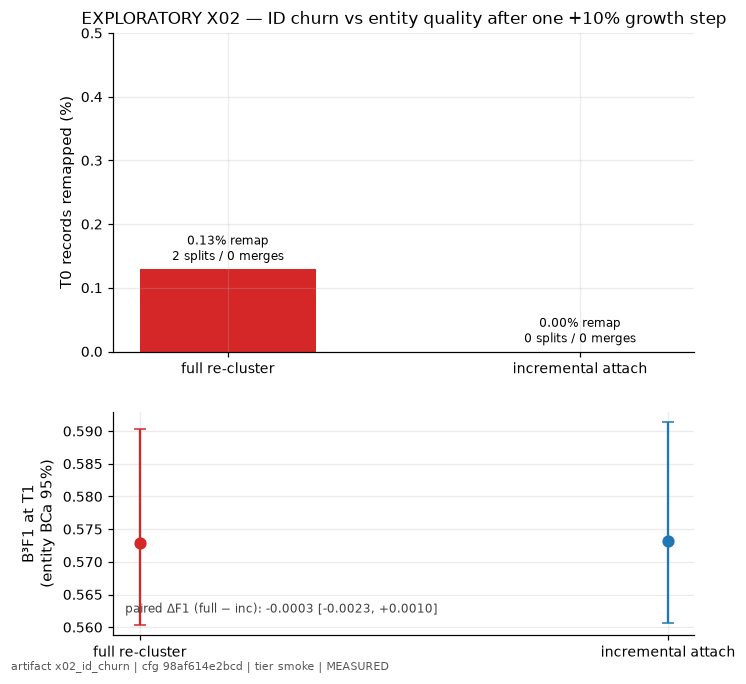

In [23]:
def draw_x02(ax, df, meta):
    pol = df[df["row_type"] == "policy"]
    order = ["full_recluster", "incremental_attach"]
    xs = np.arange(len(order))
    remap = [float(pol[pol["policy"] == p]["id_remap_frac"].iloc[0]) * 100 for p in order]
    ax.bar(xs, remap, width=0.5, color=["C3", "C0"])
    for x, p in zip(xs, order):
        r = pol[pol["policy"] == p].iloc[0]
        ax.annotate(f"{r['id_remap_frac']:.2%} remap\n{int(r['splits'])} splits / "
                    f"{int(r['merges'])} merges",
                    (x, remap[x] if remap[x] > 0 else 0.0), textcoords="offset points",
                    xytext=(0, 6), ha="center", fontsize=8)
    ax.set_xticks(xs, ["full re-cluster", "incremental attach"])
    ax.set_ylabel("T0 records remapped (%)")
    ax.set_ylim(0, max(max(remap) * 1.6, 0.5))
    axq = make_axes_locatable(ax).append_axes("bottom", size="70%", pad=0.55)
    for x, p in zip(xs, order):
        r = pol[pol["policy"] == p].iloc[0]
        axq.errorbar([x], [r["f1"]], yerr=[[r["f1"] - r["f1_lo"]], [r["f1_hi"] - r["f1"]]],
                     fmt="o", capsize=4, markersize=7, color=["C3", "C0"][x])
    d = df[df["row_type"] == "delta"].iloc[0]
    axq.text(0.02, 0.1, f"paired ΔF1 (full − inc): {d['f1']:+.4f} "
             f"[{d['f1_lo']:+.4f}, {d['f1_hi']:+.4f}]",
             transform=axq.transAxes, fontsize=8, color="0.25")
    axq.set_xticks(xs, ["full re-cluster", "incremental attach"])
    axq.set_ylabel("B³F1 at T1\n(entity BCa 95%)")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="x02_id_churn", draw=draw_x02,
    title="EXPLORATORY X02 — ID churn vs entity quality after one +10% growth step",
    figsize=(6.8, 6.2),
)

### Verdict — X02, scored against the card — EXPLORATORY

In [24]:
_full_remap = CHURN["full_recluster"]["id_remap_frac"]
p1_x02 = bool(_full_remap >= 0.01 and CHURN["incremental_attach"]["id_remap_count"] == 0)
p2_x02 = bool(0.0 <= DQ["delta"] < BAR_FULL)
refute_x02 = bool(_full_remap < 0.002
                  or (DQ["delta"] >= BAR_FULL and DQ["sign_stable"]))
x02_outcome = ("REFUTED" if refute_x02
               else "CONFIRMED" if (p1_x02 and p2_x02) else "UNEXPLAINED")
print(f"P1 (full remap >= 1%, incremental = 0): full {_full_remap:.3%}, incremental "
      f"{CHURN['incremental_attach']['id_remap_count']} -> {p1_x02}")
print(f"P2 (0 <= full−inc ΔF1 < bar {BAR_FULL:.4f}): {DQ['delta']:+.4f} -> {p2_x02}")
print(f"REFUTED clause (full remap < 0.2%: {bool(_full_remap < 0.002)}; ΔF1 >= bar and "
      f"sign-stable: {bool(DQ['delta'] >= BAR_FULL and DQ['sign_stable'])}) -> {refute_x02}")
print(f"-> outcome: {x02_outcome}")

_ = verdict_box(
    "X02",
    outcome=x02_outcome,
    evidence=(
        f"EXPLORATORY arm — hypothesis-generating, never headline evidence. x02_id_churn "
        f"(tier {TIER}; T0 = {N_R0:,} records at t*={T_STAR:.4f} "
        f"[attained={res_t0['attained']}]; +{n_batch / N_R0:.1%} arrivals = {n_dup:,} "
        f"calibrated duplicates [{EXACT_DUP_FRAC:.0%} exact copies at the measured rates] "
        f"+ {len(heldback):,} brand-new-entity records). P1 {p1_x02}: full re-cluster "
        f"remapped {_full_remap:.3%} of T0 records ({CHURN['full_recluster']['splits']} "
        f"splits, {CHURN['full_recluster']['merges']} merges) vs the 1% bar; incremental "
        f"attach remapped 0 (asserted) while refusing {n_refused:,} would-be merges. "
        f"P2 {p2_x02}: the stability price — paired full-minus-incremental B3F1 "
        f"{DQ['delta']:+.4f} [{DQ['ci_low']:+.4f}, {DQ['ci_high']:+.4f}] vs the "
        f"residual-inclusive bar {BAR_FULL:.4f} (single-seed bar {BAR_SINGLE:.4f} also "
        "quoted, per convention). Single-seed DEMONSTRATION on ONE growth step: churn "
        "compounding over many increments — the number a production owner actually needs "
        "— is exactly what the graduated experiment (closing section) would measure."
    ),
    registry=registry,
)

P1 (full remap >= 1%, incremental = 0): full 0.129%, incremental 0 -> False
P2 (0 <= full−inc ΔF1 < bar 0.0865): -0.0003 -> False
REFUTED clause (full remap < 0.2%: True; ΔF1 >= bar and sign-stable: False) -> True
-> outcome: REFUTED


> ### VERDICT: REFUTED — card `X02`
>
> **Conjecture** EXPLORATORY (PLAN §3 EXPL arm — hypothesis-generating, never headline evidence): entity-ID stability and clustering quality trade off under incremental corpus growth — a full re-cluster from scratch reshuffles the IDs of records whose neighborhoods the new arrivals perturb, while an incremental attach policy (new records join an existing cluster iff their best calibrated match clears the operating threshold, else seed a new cluster) churns no existing ID by construction but pays for that stability in entity quality, because it can neither merge nor split existing clusters as evidence accumulates.
>
> **Prediction** P1 (the churn asymmetry): full re-cluster remaps >= 1% of T0 records under max-overlap carryover, while incremental attach remaps exactly 0 — by construction, verified not assumed. P2 (the price of stability): the paired full-minus-incremental B3F1 delta at T1 is >= 0 and smaller than the MET-04 residual-inclusive single-seed bar read from met04_power_table meta. Decision rule, pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff full re-cluster remaps < 0.2% of T0 records (the churn problem this arm exists to probe is imaginary at this scale), or the full-minus-incremental B3F1 delta exceeds the bar with its paired 95% CI excluding zero (stability is quality-expensive — the tradeoff is first-order); UNEXPLAINED otherwise. Single seed, one corpus draw, one growth step: an EXPLORATORY demonstration either way.
>
> **Evidence** EXPLORATORY arm — hypothesis-generating, never headline evidence. x02_id_churn (tier smoke; T0 = 15,471 records at t*=0.9721 [attained=True]; +10.0% arrivals = 923 calibrated duplicates [98% exact copies at the measured rates] + 624 brand-new-entity records). P1 False: full re-cluster remapped 0.129% of T0 records (2 splits, 0 merges) vs the 1% bar; incremental attach remapped 0 (asserted) while refusing 14 would-be merges. P2 False: the stability price — paired full-minus-incremental B3F1 -0.0003 [-0.0023, +0.0010] vs the residual-inclusive bar 0.0865 (single-seed bar 0.0862 also quoted, per convention). Single-seed DEMONSTRATION on ONE growth step: churn compounding over many increments — the number a production owner actually needs — is exactly what the graduated experiment (closing section) would measure.


## 6. EFF-02 — the static-distilled encoder — EXPLORATORY

The teacher runs a transformer per record; the student is a **lookup**: hash the record's
char {3,4}-grams into 4096 dims, L2-normalize, multiply by one 4096x128 ridge-fitted
matrix. No labels touch the distillation — the student regresses the teacher's embeddings
of the TRAIN-half records on the identical serialized texts (fit half), and is judged on
the eval half. Retrieval quality is scored on **raw student/teacher cosines, rank-native**;
the operating point keeps calibrated probabilities (each model gets its own isotonic map on
the shared labeled train pair sample, rescored — a stated economy).

In [25]:
def ngram_matrix(texts: list[str]) -> sparse.csr_matrix:
    """Hashed char n-gram count features, one L2-normalized row per text."""
    indptr = [0]
    idx_parts: list[np.ndarray] = []
    val_parts: list[np.ndarray] = []
    for t in texts:
        b = np.frombuffer(t.encode("utf-8"), dtype=np.uint8).astype(np.int64)
        hs = []
        for n in NGRAM_NS:
            if len(b) >= n:
                m = len(b) - n + 1
                h = np.zeros(m, dtype=np.int64)
                for off in range(n):
                    h = h * 257 + b[off: off + m]
                hs.append((h + 2654435761 * n) % D_HASH)
        if hs:
            cols, cnts = np.unique(np.concatenate(hs), return_counts=True)
            vec = cnts.astype(np.float64)
            vec /= np.linalg.norm(vec)
            idx_parts.append(cols)
            val_parts.append(vec)
            indptr.append(indptr[-1] + len(cols))
        else:
            indptr.append(indptr[-1])
    return sparse.csr_matrix(
        (np.concatenate(val_parts) if val_parts else np.zeros(0),
         np.concatenate(idx_parts) if idx_parts else np.zeros(0, dtype=np.int64),
         np.asarray(indptr, dtype=np.int64)),
        shape=(len(texts), D_HASH),
    )


t_sec = time.time()
TR_TEXTS = [ARENA_TEXTS[i] for i in tr_pos]
_t0 = time.time()
X_TR = ngram_matrix(TR_TEXTS)
Y_TR = EMB[tr_pos].astype(np.float64)
XtX = np.asarray((X_TR.T @ X_TR).todense())
XtY = np.asarray(X_TR.T @ Y_TR)
W_STUDENT = np.linalg.solve(XtX + RIDGE_LAMBDA * np.eye(D_HASH), XtY)
FIT_SECS = time.time() - _t0
print(f"student fitted: closed-form ridge (lambda={RIDGE_LAMBDA}, untuned) on "
      f"{X_TR.shape[0]:,} TRAIN-half records x {D_HASH} hashed {NGRAM_NS}-gram features -> "
      f"{W_STUDENT.shape[0]}x{W_STUDENT.shape[1]} map "
      f"({W_STUDENT.size:,} params) in {FIT_SECS:.0f}s; the teacher has {N_PARAMS:,} params")


def student_encode(texts: list[str]) -> np.ndarray:
    """Static encode: hashed n-gram features x the ridge map, rows L2-normalized."""
    x = ngram_matrix(texts)
    emb = np.asarray(x @ W_STUDENT, dtype=np.float32)
    nrm = np.linalg.norm(emb, axis=1, keepdims=True)
    nrm[nrm == 0.0] = 1.0
    return emb / nrm


# back-to-back throughput on the identical serialized corpus (same contention window)
_t0 = time.time()
EMB_STUDENT = student_encode(ARENA_TEXTS)
STUDENT_SECS = time.time() - _t0
STUDENT_RATE = N_ARENA / STUDENT_SECS
_t0 = time.time()
_ = encoder.encode(ARENA_TEXTS, batch_size=ENC_BATCH)
TEACHER_SECS2 = time.time() - _t0
TEACHER_RATE2 = N_ARENA / TEACHER_SECS2
SPEEDUP = STUDENT_RATE / TEACHER_RATE2
print(f"encode throughput, back-to-back on the same {N_ARENA:,} texts: student "
      f"{STUDENT_RATE:,.0f} rec/s ({STUDENT_SECS:.1f}s) vs teacher {TEACHER_RATE2:,.0f} "
      f"rec/s ({TEACHER_SECS2:.0f}s; §3 measured {ENC_RATE:,.0f}) -> speedup "
      f"{SPEEDUP:.1f}x (P2 bar: >= 20x; both timings share this container's contention)")

ev_pos = ARENA_POS.loc[eval_full["record_id"].astype(str)].to_numpy()
_fid_ev = float(np.mean(np.einsum("ij,ij->i", EMB[ev_pos], EMB_STUDENT[ev_pos])))
_fid_tr = float(np.mean(np.einsum("ij,ij->i", EMB[tr_pos], EMB_STUDENT[tr_pos])))
print(f"distillation fidelity (mean teacher-student cosine per record): {_fid_tr:.4f} on "
      f"the fit half vs {_fid_ev:.4f} on the eval half — the fit-to-transfer gap")
tick("§6a student fit + throughput", t_sec)

student fitted: closed-form ridge (lambda=1.0, untuned) on 16,164 TRAIN-half records x 4096 hashed (3, 4)-gram features -> 4096x128 map (524,288 params) in 5s; the teacher has 330,880 params


encode throughput, back-to-back on the same 32,259 texts: student 14,384 rec/s (2.2s) vs teacher 1,267 rec/s (25s; §3 measured 1,647) -> speedup 11.4x (P2 bar: >= 20x; both timings share this container's contention)
distillation fidelity (mean teacher-student cosine per record): 0.9209 on the fit half vs 0.8438 on the eval half — the fit-to-transfer gap
[section timing] §6a student fit + throughput: 32s


In [26]:
# PC at matched k, teacher vs student — raw cosines, rank-native.
t_sec = time.time()
ev_tools = make_pc_tools(eval_full, PRIMARY_SEED + 47)
print(f"eval-half PC arena: {len(eval_full):,} records, {len(ev_tools['pairs']):,} true "
      f"pairs over {ev_tools['n_entities']:,} multi-record entities")
EV_EMB = {"teacher": np.ascontiguousarray(EMB[ev_pos]),
          "student": np.ascontiguousarray(EMB_STUDENT[ev_pos])}
PC_ROWS: list[dict] = []
FOUND_EV: dict[tuple[str, int], np.ndarray] = {}
CAND10: dict[str, pd.DataFrame] = {}
for _model, _emb in EV_EMB.items():
    for _k in PC_KS:
        cand = ann.candidates(eval_full, _emb, k=_k, index="flat")
        if _k == K_CAND:
            CAND10[_model] = cand
        keys = set((cand["a"].astype(str) + "||" + cand["b"].astype(str)).tolist())
        fm = ev_tools["found_mask"](keys)
        FOUND_EV[(_model, _k)] = fm
        pc, lo, hi = ev_tools["pc_ci"](fm)
        PC_ROWS.append({"row_type": "pc", "model": _model, "k": float(_k), "pc": pc,
                        "pc_lo": lo, "pc_hi": hi, "basis": "MEASURED"})
        print(f"  [{_model} k={_k}] PC={pc:.4f} [{lo:.4f},{hi:.4f}]")
_pct = {(r["model"], int(r["k"])): r["pc"] for r in PC_ROWS}
RETENTION = _pct[("student", K_CAND)] / _pct[("teacher", K_CAND)]
D10, D10_LO, D10_HI = ev_tools["delta_ci"](FOUND_EV[("student", K_CAND)],
                                           FOUND_EV[("teacher", K_CAND)])
print(f"retention at k={K_CAND}: student/teacher = {RETENTION:.3f} (paired PC delta "
      f"{D10:+.4f} [{D10_LO:+.4f},{D10_HI:+.4f}]; P1 bar: >= 0.90)")
tick("§6b student vs teacher PC", t_sec)

eval-half PC arena: 16,095 records, 187,785 true pairs over 991 multi-record entities


  [teacher k=5] PC=0.2352 [0.2260,0.2453]


  [teacher k=10] PC=0.3716 [0.3577,0.3862]


  [teacher k=25] PC=0.5464 [0.5268,0.5678]


  [student k=5] PC=0.2341 [0.2249,0.2452]


  [student k=10] PC=0.3741 [0.3599,0.3897]


  [student k=25] PC=0.5638 [0.5453,0.5834]
retention at k=10: student/teacher = 1.007 (paired PC delta +0.0025 [-0.0020,+0.0065]; P1 bar: >= 0.90)
[section timing] §6b student vs teacher PC: 16s


In [27]:
# Entity-F at the precision-0.99 operating point — calibrated probs, per convention.
t_sec = time.time()
truth_ev = eval_full.set_index(eval_full["record_id"].astype(str))["entity_id"]
records_ev = pd.Index(truth_ev.index)
OP_ROWS: list[dict] = []
OP_PRED: dict[str, pd.Series] = {}
for _model in ("teacher", "student"):
    _emb_ev = EV_EMB[_model]
    _posmap = pd.Series(np.arange(len(eval_full)), index=records_ev)
    gm = CAND10[_model][["a", "b"]].copy()
    gm["a"], gm["b"] = gm["a"].astype(str), gm["b"].astype(str)
    gm["cos"] = pair_cosines(_emb_ev, _posmap, gm["a"], gm["b"])
    if _model == "teacher":
        iso_m = iso_teacher
    else:
        _s_cos = pair_cosines(EMB_STUDENT, ARENA_POS, calpairs["a"], calpairs["b"])
        iso_m = fit_calibrator(_s_cos, calpairs["label"].to_numpy(), method="isotonic")
    gm["prob"] = iso_m.transform(gm["cos"].to_numpy())
    gm["score"] = gm["prob"]
    cache_m: dict[float, pd.Series] = {}

    def closure_m(t: float, _g=gm, _c=cache_m) -> pd.Series:
        t = float(t)
        if t not in _c:
            _c[t] = transitive_closure(_g, threshold=t, records=records_ev)
        return _c[t]

    res_m = find_threshold_for_precision(
        gm[["a", "b", "score"]], closure_m, truth_ev, target=PREC_TARGET, grid=GRID)
    pred_m = closure_m(res_m["threshold"])
    OP_PRED[_model] = pred_m
    row = {"row_type": "op", "model": _model, "threshold": float(res_m["threshold"]),
           "attained": float(res_m["attained"]), "basis": "MEASURED"}
    for short, metric in (("precision", "bcubed_precision"), ("recall", "bcubed_recall"),
                          ("f1", "bcubed_f1")):
        res = bootstrap_ci(pred_m, truth_ev, metric, unit="entity", n_boot=N_BOOT,
                           seed=PRIMARY_SEED)
        row[short] = res["point"]
        row[f"{short}_lo"], row[f"{short}_hi"] = res["ci_low"], res["ci_high"]
    OP_ROWS.append(row)
    flag = "" if res_m["attained"] else (f"  <-- {PREC_TARGET} UNATTAINABLE "
                                         f"(fallback='{res_m['fallback']}', PLAN §5 rail)")
    print(f"  [{_model}] precision@{PREC_TARGET}: t={res_m['threshold']:.4f} -> B3 "
          f"P={row['precision']:.4f} R={row['recall']:.4f} F={row['f1']:.4f} "
          f"[{row['f1_lo']:.4f},{row['f1_hi']:.4f}]{flag}")
DF_OP = paired_delta(OP_PRED["teacher"], OP_PRED["student"], truth_ev, "bcubed_f1",
                     unit="entity", n_boot=N_BOOT, seed=PRIMARY_SEED)
print(f"paired teacher − student B3F1 at the operating point: {DF_OP['delta']:+.4f} "
      f"[{DF_OP['ci_low']:+.4f},{DF_OP['ci_high']:+.4f}] (sign-stable: "
      f"{DF_OP['sign_stable']}) vs the residual-inclusive bar {BAR_FULL:.4f}")

eff02_rows = PC_ROWS + OP_ROWS + [
    {"row_type": "throughput", "model": "teacher", "records_per_sec": TEACHER_RATE2,
     "ms_per_record": 1e3 / TEACHER_RATE2, "basis": "MEASURED"},
    {"row_type": "throughput", "model": "student", "records_per_sec": STUDENT_RATE,
     "ms_per_record": 1e3 / STUDENT_RATE, "basis": "MEASURED"},
    {"row_type": "delta", "model": "teacher_minus_student_op_f1", "f1": DF_OP["delta"],
     "f1_lo": DF_OP["ci_low"], "f1_hi": DF_OP["ci_high"],
     "sign_stable": float(DF_OP["sign_stable"]), "basis": "MEASURED"},
    {"row_type": "delta", "model": "retention_pc10", "pc": RETENTION, "pc_lo": np.nan,
     "pc_hi": np.nan, "basis": "MEASURED"},
]
eff02_df = pd.DataFrame(eff02_rows)
registry.register(
    "eff02_static_distill", eff02_df, cfg=cfg, tier=cfg.run.tier,
    meta={
        "card": "EFF-02",
        "status": "EXPLORATORY (PLAN §3 EXPL arm) — hypothesis-generating, never headline "
                  "evidence",
        "student": {"features": f"char {list(NGRAM_NS)}-grams hashed to {D_HASH} dims, "
                                "count-weighted, row-L2-normalized",
                    "fit": f"closed-form ridge (lambda={RIDGE_LAMBDA}, untuned) regressing "
                           "teacher embeddings of the TRAIN-half records on identical "
                           "serialized texts; no labels used",
                    "params": int(W_STUDENT.size), "fit_secs": FIT_SECS,
                    "fidelity_cos": {"fit_half": _fid_tr, "eval_half": _fid_ev}},
        "teacher": {"statement": "NB12 recipe stated, not read: infonce/inbatch/none, "
                                 "scratch_char", "model": dict(MODEL_SHAPE),
                    "steps": STEPS, "batch": BATCH, "n_params": N_PARAMS},
        "scored_representation": "PC rows: RAW teacher/student cosines, rank-native "
                                 "(binding convention). op rows: calibrated probabilities "
                                 "(per-model global isotonic on the shared labeled "
                                 "TRAIN-half pair sample, rescored per model — a stated "
                                 "economy vs refitting each model's own candidate "
                                 "distribution), thresholds at B3 "
                                 f"precision@{PREC_TARGET} with the PLAN §5 loud-fallback "
                                 "rail",
        "throughput": "back-to-back on the identical serialized corpus in one contention "
                      "window; the ratio, not the absolute rates, is the claim",
        "ci": {"unit": "entity", "pc": "percentile bootstrap, shared resamples",
               "op": "BCa via er_lab.eval.bootstrap", "n_boot": N_BOOT},
        "met04": {"detect_bar_single_seed": BAR_SINGLE,
                  "detect_bar_residual_inclusive": BAR_FULL, "units": "B3F1"},
        "single_seed_caveat": "one teacher (one seed, one corpus draw), one ridge fit — "
                              "an EXPLORATORY demonstration",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"registered eff02_static_distill ({len(eff02_df)} rows)")
tick("§6c operating points + register", t_sec)

  [teacher] precision@0.99: t=0.9721 -> B3 P=0.9905 R=0.4038 F=0.5737 [0.5596,0.5880]


  [student] precision@0.99: t=0.9947 -> B3 P=0.9984 R=0.3472 F=0.5152 [0.4997,0.5279]
paired teacher − student B3F1 at the operating point: +0.0585 [+0.0497,+0.0672] (sign-stable: True) vs the residual-inclusive bar 0.0865
registered eff02_static_distill (12 rows)
[section timing] §6c operating points + register: 16s


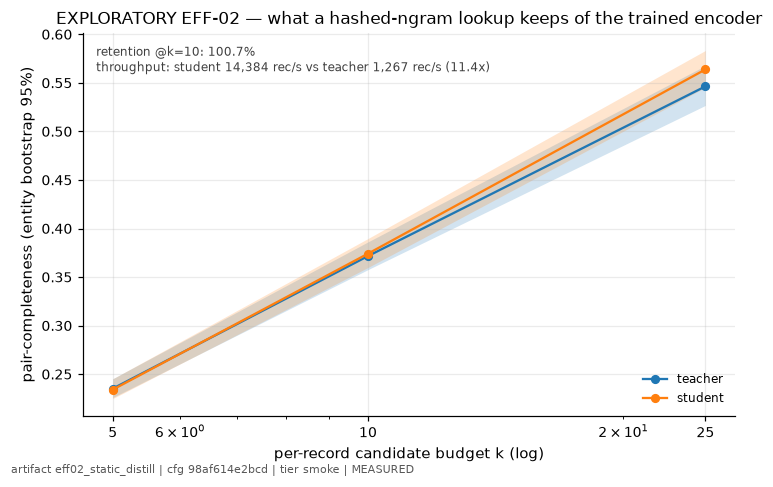

In [28]:
def draw_eff02(ax, df, meta):
    pc = df[df["row_type"] == "pc"]
    for model, color in (("teacher", "C0"), ("student", "C1")):
        g = pc[pc["model"] == model].sort_values("k")
        (line,) = ax.plot(g["k"], g["pc"], "-o", color=color, label=model, markersize=5)
        ax.fill_between(g["k"], g["pc_lo"], g["pc_hi"], alpha=0.2,
                        color=line.get_color(), linewidth=0)
    thr = df[df["row_type"] == "throughput"].set_index("model")["records_per_sec"]
    ret = df[(df["row_type"] == "delta") & (df["model"] == "retention_pc10")]["pc"].iloc[0]
    ax.text(0.02, 0.97,
            f"retention @k=10: {ret:.1%}\n"
            f"throughput: student {thr['student']:,.0f} rec/s vs "
            f"teacher {thr['teacher']:,.0f} rec/s "
            f"({thr['student'] / thr['teacher']:.1f}x)",
            transform=ax.transAxes, va="top", fontsize=8, color="0.25")
    ax.set_xscale("log")
    ax.set_xticks(list(PC_KS), [str(k) for k in PC_KS])
    ax.set_xlabel("per-record candidate budget k (log)")
    ax.set_ylabel("pair-completeness (entity bootstrap 95%)")
    ax.legend(loc="lower right", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="eff02_static_distill", draw=draw_eff02,
    title="EXPLORATORY EFF-02 — what a hashed-ngram lookup keeps of the trained encoder",
    figsize=(6.8, 4.4),
)

### Verdict — EFF-02, scored against the card — EXPLORATORY

In [29]:
p1_eff = bool(RETENTION >= 0.90)
p2_eff = bool(SPEEDUP >= 20.0)
p3_eff = bool(abs(DF_OP["delta"]) < BAR_FULL)
refute_eff = bool(RETENTION < 0.75 or SPEEDUP < 5.0)
eff_outcome = ("REFUTED" if refute_eff
               else "CONFIRMED" if (p1_eff and p2_eff) else "UNEXPLAINED")
print(f"P1 (retention >= 0.90): {RETENTION:.3f} -> {p1_eff}")
print(f"P2 (speedup >= 20x): {SPEEDUP:.1f}x -> {p2_eff}")
print(f"P3 (op-point |ΔF1| < bar, subordinate): |{DF_OP['delta']:+.4f}| vs {BAR_FULL:.4f} "
      f"-> {p3_eff}")
print(f"REFUTED clause (retention < 0.75: {bool(RETENTION < 0.75)}; speedup < 5x: "
      f"{bool(SPEEDUP < 5.0)}) -> {refute_eff}")
print(f"-> outcome: {eff_outcome}")

_ = verdict_box(
    "EFF-02",
    outcome=eff_outcome,
    evidence=(
        f"EXPLORATORY arm — hypothesis-generating, never headline evidence. "
        f"eff02_static_distill (tier {TIER}; eval half, {len(ev_tools['pairs']):,} true "
        f"pairs, {N_BOOT} shared entity resamples). P1 {p1_eff}: student PC@{K_CAND} "
        f"{_pct[('student', K_CAND)]:.4f} vs teacher {_pct[('teacher', K_CAND)]:.4f} = "
        f"{RETENTION:.1%} retention (paired delta {D10:+.4f} [{D10_LO:+.4f}, "
        f"{D10_HI:+.4f}]) against the 0.90 bar. P2 {p2_eff}: {SPEEDUP:.1f}x measured "
        f"back-to-back ({STUDENT_RATE:,.0f} vs {TEACHER_RATE2:,.0f} rec/s on this "
        f"container) against the 20x bar. P3 {p3_eff} (subordinate): operating-point "
        f"teacher-minus-student B3F1 {DF_OP['delta']:+.4f} [{DF_OP['ci_low']:+.4f}, "
        f"{DF_OP['ci_high']:+.4f}] vs the residual-inclusive bar {BAR_FULL:.4f} "
        f"(single-seed bar {BAR_SINGLE:.4f} also quoted). Fidelity: mean teacher-student "
        f"cosine {_fid_tr:.4f} fit-half vs {_fid_ev:.4f} eval-half. Single-seed "
        "DEMONSTRATION: one teacher, one ridge fit, one corpus draw; the honest reading "
        "is whichever way these numbers landed, stated above, and the graduation criteria "
        "below say what a pre-registered EFF-02 (with the eff01 compression frontier as "
        "the comparison axis) would need."
    ),
    registry=registry,
)

P1 (retention >= 0.90): 1.007 -> True
P2 (speedup >= 20x): 11.4x -> False
P3 (op-point |ΔF1| < bar, subordinate): |+0.0585| vs 0.0865 -> True
REFUTED clause (retention < 0.75: False; speedup < 5x: False) -> False
-> outcome: UNEXPLAINED


> ### VERDICT: UNEXPLAINED — card `EFF-02`
>
> **Conjecture** EXPLORATORY (PLAN §3 EXPL arm — hypothesis-generating, never headline evidence): most of what the trained char transformer knows about person-record similarity is surface n-gram evidence, so a STATIC embedding — hashed character n-gram counts pushed through one linear map distilled from the teacher by closed-form ridge regression — retains most of the teacher's blocking quality at a large measured encode speedup, making ~100x-cheaper inference a plausible blocking tier for scale designs (the EFF-02 question).
>
> **Prediction** P1 (retention): student PC@10 >= 90% of teacher PC@10 (eval half, point estimates). P2 (speedup): student encode throughput >= 20x the teacher's, both measured back-to-back on the identical texts. P3 (subordinate, cannot flip the outcome): the teacher-minus-student B3F1 delta at the precision-0.99 operating point is within the MET-04 residual-inclusive single-seed bar. Decision rule, pre-registered: CONFIRMED iff P1 and P2 both hold; REFUTED iff retention < 75% OR speedup < 5x (the arm is not worth a follow-up in either failure mode); UNEXPLAINED otherwise. One teacher (one seed, one corpus draw), one ridge fit: an EXPLORATORY demonstration; the honest conclusion is reported whichever way it lands.
>
> **Evidence** EXPLORATORY arm — hypothesis-generating, never headline evidence. eff02_static_distill (tier smoke; eval half, 187,785 true pairs, 400 shared entity resamples). P1 True: student PC@10 0.3741 vs teacher 0.3716 = 100.7% retention (paired delta +0.0025 [-0.0020, +0.0065]) against the 0.90 bar. P2 False: 11.4x measured back-to-back (14,384 vs 1,267 rec/s on this container) against the 20x bar. P3 True (subordinate): operating-point teacher-minus-student B3F1 +0.0585 [+0.0497, +0.0672] vs the residual-inclusive bar 0.0865 (single-seed bar 0.0862 also quoted). Fidelity: mean teacher-student cosine 0.9209 fit-half vs 0.8438 eval-half. Single-seed DEMONSTRATION: one teacher, one ridge fit, one corpus draw; the honest reading is whichever way these numbers landed, stated above, and the graduation criteria below say what a pre-registered EFF-02 (with the eff01 compression frontier as the comparison axis) would need.


## 7. Closing — what each arm would need to graduate — EXPLORATORY

The whole point of an exploratory arm is a cheap, honest answer to "is the full experiment
worth its compute?" The registered numbers above are single-seed demonstrations on a ~3e4
corpus; **none of them is evidence for a headline claim**, and each names its own
graduation bar:

- **X01 -> a pre-registered reranker experiment** needs: multi-seed replicates sized by
  `met04_power_table` at mid tier (both the bi-encoder and the reranker are trained
  artifacts with run-to-run noise); the pretrained cross-encoder arm run on the mac (the
  gated cell above); a cost model that amortizes reranker *training* as well as scoring;
  and the value-per-dollar framing of PLAN §3's X01 row — PC per ms is the deciding axis,
  not PC alone. The oracle-ceiling instrument registered here transfers as-is.
- **X02 -> a pre-registered churn experiment** needs: MANY growth steps (churn compounds;
  one step cannot show the compounding), temporal-drift arrival mixes (NB04's measured
  drift channels, not just duplication), the threshold-retuning policy axis (frozen vs
  re-tuned per increment), and hub-dense corpora at mid/target scale where full re-cluster
  has real merge fuel. The churn ledger definitions (max-overlap carryover, refused
  merges) are the reusable instruments.
- **EFF-02 -> a pre-registered distillation experiment** needs: the eff01 compression
  frontier as the comparison axis (a static student must beat MRL-truncation + int8 at
  matched quality to earn a lane), multi-seed teachers, a tuned-lambda/feature-dimension
  sweep with a held-out fit split, and target-tier index-size effects (hashed features
  collide harder at 1e7 names). The back-to-back throughput protocol transfers as-is.

In [30]:
# [RUN-IN-TARGET mac] the definitive appendix arms: THESE same cells at tier=mid on the mac
# (PLAN §3 puts all three EXPL arms at mid). Priced from THIS run's measured coefficients
# (4-CPU container, 2 sibling builds contending; planning numbers, re-measured on arrival):
if TIER in ("mid", "target"):
    print(f"tier={TIER}: the arms above ARE the definitive exploratory runs at this tier; "
          "replicate counts per met04_power_table at this tier.")
else:
    _mid_steps = STEPS_BY_TIER["mid"]
    _scale = 1e6 / N_ARENA
    print("[RUN-IN-TARGET mac] mid-tier appendix, priced from this run's coefficients:")
    print(f"  encoders: bi {TRAIN_SECS:.0f}s + cross {XTRAIN_SECS:.0f}s at {STEPS} steps "
          f"-> x{_mid_steps / STEPS:.0f} steps at mid = "
          f"~{(TRAIN_SECS + XTRAIN_SECS) * _mid_steps / STEPS / 60:.0f} min per seed pair "
          "on this CPU; MPS is faster (PLAN §8: ~0.2-0.3x A100)")
    print(f"  X01 scoring: {X_MS_PER_PAIR:.2f} ms/pair measured -> a 1e6-record arena at "
          f"k={K_RETR} is ~{1e6 * K_RETR * 0.7:.0e} unique pairs = "
          f"~{1e6 * K_RETR * 0.7 * X_MS_PER_PAIR / 1e3 / 3600:.0f} h/seed on this CPU — "
          "the mac batch-parallelizes; the pretrained arm adds its own measured rate")
    print(f"  X02: T0 sweep {res_t0['curve'].shape[0]} thresholds took the §5 timings "
          f"below; at 1e6 records the closure sweep scales ~linearly in kept pairs "
          f"(~{_scale:.0f}x) and stays minutes; many-step churn = ~10 increments x that")
    print(f"  EFF-02: ridge fit {FIT_SECS:.0f}s at {D_HASH} dims (cubic in dims: 8192 "
          f"-> ~{FIT_SECS * 8:.0f}s); student encode {STUDENT_RATE:,.0f} rec/s measured "
          f"-> 1e6 records in ~{1e6 / STUDENT_RATE / 60:.1f} min single-thread")

[RUN-IN-TARGET mac] mid-tier appendix, priced from this run's coefficients:
  encoders: bi 36s + cross 19s at 250 steps -> x8 steps at mid = ~7 min per seed pair on this CPU; MPS is faster (PLAN §8: ~0.2-0.3x A100)
  X01 scoring: 0.58 ms/pair measured -> a 1e6-record arena at k=25 is ~2e+07 unique pairs = ~3 h/seed on this CPU — the mac batch-parallelizes; the pretrained arm adds its own measured rate
  X02: T0 sweep 60 thresholds took the §5 timings below; at 1e6 records the closure sweep scales ~linearly in kept pairs (~31x) and stays minutes; many-step churn = ~10 increments x that
  EFF-02: ridge fit 5s at 4096 dims (cubic in dims: 8192 -> ~36s); student encode 14,384 rec/s measured -> 1e6 records in ~1.2 min single-thread


**Artifacts registered** (exact names): `x01_reranker_value`, `x02_id_churn`,
`eff02_static_distill` — plus the immutable cards `card_X01`, `card_X02`, `card_EFF-02`.

**Package gaps noted this notebook** (worked around in-notebook, per the series
convention): `blocking.ann` exposes no per-record directed neighbor lists (rebuilt here,
asserted against the module's pair set); no cross-encoder regime in `models.encoders`
(tiny scratch cross-encoder defined in-notebook); no incremental/streaming attach API in
`cluster.schemes` (attach loop in-notebook); no static/distilled encoder home (hashed
n-gram student in-notebook); NB05's custom `move`/`name_change`/`name_format_drift`
channels live in its notebook, not the package (compact clones here);
`entity_complete_subsample` still notebook-local (05/09/12/13/A);
`er_lab.eval.bootstrap` targets clusterings, not candidate sets (notebook-local PC
bootstrap, as in NB12).

In [31]:
timing = pd.DataFrame(SECTION_TIMES, columns=["section", "secs"])
display(timing.assign(secs=timing["secs"].round(0)))
total = time.time() - NB_T0
print(f"notebook wall-clock: {total:.0f}s ({total / 60:.1f} min) — smoke budget <= ~30 min "
      "uncontended"
      + ("" if total <= 2100 else "  <-- over that budget at this run (see section table; "
                                  "two sibling notebook builds contend for these 4 CPUs)"))

,section,secs
0,§1 arena + bars,1.0
1,§2 cards,0.0
2,§3a teacher train,36.0
3,§3b teacher encode,20.0
4,§3c calibrator,4.0
5,§4a X01 arena + pool,1.0
6,§4b cross-encoder train,22.0
7,§4c score + rerank + ledger,39.0
8,§4d X01 register + verdict,0.0
9,§5a X02 T0 cluster,9.0


notebook wall-clock: 203s (3.4 min) — smoke budget <= ~30 min uncontended
